# MeatLens Final CNN-Only Thesis Notebook

This notebook is the final **CNN-only MeatLens thesis pipeline** built around the current split files in `generated_splits/`.

It is designed for the final thesis experiment with:
- `cross_rotation` as the primary strict generalization test
- `random_70_15_15` as a secondary baseline
- `center_crop` as the default preprocessing mode to simulate the guided square capture box used in the planned mobile workflow

Models compared:
1. `MobileNetV3Small`
2. `EfficientNetB0`
3. `ResNet50`
4. `MobileNetV2`

Scientific framing:
- This notebook is **CNN-only baseline training**
- It does **not** use handcrafted GLCM/color features for training yet
- It does **not** use the public dataset
- It does **not** use time as a model input
- **Macro F1-score** is the primary model-comparison metric
- MeatLens is treated as a **decision-support tool**, not a replacement for licensed inspectors


In [1]:
# ============================================================
# Libraries
# ============================================================
import gc
import io
import json
import math
import random
import shutil
import time
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except Exception:
    sns = None
    SEABORN_AVAILABLE = False

from PIL import Image, ImageOps

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight

TF_AVAILABLE = True
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
    from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, MobileNetV3Small, ResNet50
    from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_efficientnetb0
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenetv2
    from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as preprocess_mobilenetv3
    from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet50
except Exception as e:
    TF_AVAILABLE = False
    tf = None
    print(f"[WARN] TensorFlow is not available: {e}")

plt.style.use("default")
warnings.filterwarnings("ignore")
print("TF_AVAILABLE =", TF_AVAILABLE)
print("SEABORN_AVAILABLE =", SEABORN_AVAILABLE)


TF_AVAILABLE = True
SEABORN_AVAILABLE = True


In [3]:
# ============================================================
# Environment verification
# Run this before any training starts
# ============================================================
import os
import sys

print("Python executable:", sys.executable)

if not TF_AVAILABLE:
    print("TensorFlow version: NOT AVAILABLE")
    print("Detected GPU list: []")
    print("DirectML GPU available: False")
else:
    print("TensorFlow version:", tf.__version__)
    gpu_list = tf.config.list_physical_devices("GPU")
    print("Detected GPU list:", gpu_list)

    directml_available = False
    try:
        directml_available = any("GPU" in str(device) for device in gpu_list)
    except Exception:
        directml_available = False
    print("DirectML GPU available:", directml_available)

kernel_name = None
try:
    kernel_name = os.environ.get("VSCODE_IPYTHON_KERNEL_NAME")
    if not kernel_name:
        kernel_name = os.environ.get("JPY_SESSION_NAME")
    if not kernel_name:
        from ipykernel import get_connection_file
        kernel_name = get_connection_file()
except Exception:
    kernel_name = "Unavailable"
print("Current notebook kernel:", kernel_name)

if (not TF_AVAILABLE) or (len(tf.config.list_physical_devices("GPU")) == 0):
    print("\n[WARNING] No GPU was detected.")
    print("Do not run full training yet.")
    print("Verify that the notebook is using the 'Python 3.10 (MeatLens GPU)' kernel and that TensorFlow DirectML is available.")
else:
    print("\nEnvironment check passed. GPU appears available for training.")


Python executable: e:\Thesis Code\.venv-gpu\Scripts\python.exe
TensorFlow version: 2.10.0
Detected GPU list: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
DirectML GPU available: True
Current notebook kernel: e:\Thesis Code\.jupyter_runtime\kernel-v3de54264fdd421be506aa29324db36778b2836bf3.json

Environment check passed. GPU appears available for training.


In [4]:
# ============================================================
# Final thesis configuration
# ============================================================
PROJECT_ROOT = Path.cwd()
GENERATED_SPLITS_ROOT = PROJECT_ROOT / "generated_splits"
CROSS_ROOT = GENERATED_SPLITS_ROOT / "cross_rotation"
RANDOM_ROOT = GENERATED_SPLITS_ROOT / "random_70_15_15"

TRAINING_OUTPUTS = PROJECT_ROOT / "training_outputs"
FIGURES_DIR = TRAINING_OUTPUTS / "figures"
MODELS_DIR = TRAINING_OUTPUTS / "models"
FEATURES_DIR = TRAINING_OUTPUTS / "features"

TRAINING_OUTPUTS.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_INPUT_MODE = "cnn_only"
SPLIT_MODE = "cross_rotation"
IMAGE_CROP_MODE = "center_crop"
RUN_SEEDS = [42, 123, 2026]
BACKBONES = ["MobileNetV3Small", "EfficientNetB0"]
RUN_FULL_TRAINING = True

# For quick debugging only:
# MODEL_INPUT_MODE = "cnn_only"
# SPLIT_MODE = "cross_rotation"
# IMAGE_CROP_MODE = "center_crop"
# RUN_SEEDS = [42]
# BACKBONES = ["MobileNetV2"]
# RUN_FULL_TRAINING = False

TARGET_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = 3
BATCH_SIZE = 32
EPOCHS_HEAD = 8
EPOCHS_FINE = 20
HEAD_LR = 5e-4
WEIGHT_DECAY = 1e-4

LABEL_ORDER = ["fresh", "not fresh", "spoiled"]
LABEL_TO_INDEX = {label: idx for idx, label in enumerate(LABEL_ORDER)}
INDEX_TO_LABEL = {idx: label for label, idx in LABEL_TO_INDEX.items()}

FINE_TUNE_LR = {
    "MobileNetV3Small": 1e-5,
    "EfficientNetB0": 1e-5,
    "ResNet50": 5e-6,
    "MobileNetV2": 1e-5,
}

FINE_TUNE_FRACTION = {
    "MobileNetV3Small": 0.25,
    "EfficientNetB0": 0.20,
    "ResNet50": 0.15,
    "MobileNetV2": 0.20,
}

IMAGE_PATH_CANDIDATES = [
    "image_path",
    "file_path",
    "path",
    "filename",
    "image_file",
    "roi_file",
    "file_destination",
]

ROI_COLUMN_GROUPS = [
    ("x", "y", "w", "h"),
    ("xmin", "ymin", "xmax", "ymax"),
    ("bbox_x", "bbox_y", "bbox_w", "bbox_h"),
]
ROI_ALL_COLUMNS = sorted({col for group in ROI_COLUMN_GROUPS for col in group})

SHARPEN_KERNEL = [
    [0.0, -1.0, 0.0],
    [-1.0, 5.0, -1.0],
    [0.0, -1.0, 0.0],
]

print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"SPLIT_MODE={SPLIT_MODE}")
print(f"IMAGE_CROP_MODE={IMAGE_CROP_MODE}")
print(f"RUN_SEEDS={RUN_SEEDS}")
print(f"BACKBONES={BACKBONES}")
print(f"RUN_FULL_TRAINING={RUN_FULL_TRAINING}")


PROJECT_ROOT=e:\Thesis Code
SPLIT_MODE=cross_rotation
IMAGE_CROP_MODE=center_crop
RUN_SEEDS=[42, 123, 2026]
BACKBONES=['MobileNetV3Small', 'EfficientNetB0']
RUN_FULL_TRAINING=True


In [5]:
# ============================================================
# Split files and expected held-out mapping
# ============================================================
CROSS_FILES = {
    "fold1_train": CROSS_ROOT / "fold1_train.csv",
    "fold1_val": CROSS_ROOT / "fold1_val.csv",
    "fold1_test": CROSS_ROOT / "fold1_test.csv",
    "fold2_train": CROSS_ROOT / "fold2_train.csv",
    "fold2_val": CROSS_ROOT / "fold2_val.csv",
    "fold2_test": CROSS_ROOT / "fold2_test.csv",
    "fold3_train": CROSS_ROOT / "fold3_train.csv",
    "fold3_val": CROSS_ROOT / "fold3_val.csv",
    "fold3_test": CROSS_ROOT / "fold3_test.csv",
    "fold4_train": CROSS_ROOT / "fold4_train.csv",
    "fold4_val": CROSS_ROOT / "fold4_val.csv",
    "fold4_test": CROSS_ROOT / "fold4_test.csv",
}

RANDOM_FILES = {
    "random_train": RANDOM_ROOT / "random_train.csv",
    "random_val": RANDOM_ROOT / "random_val.csv",
    "random_test": RANDOM_ROOT / "random_test.csv",
}

EXPECTED_CROSS_HOLDOUTS = {
    "fold1": {"held_out_sample": "pork_shoulder_sample_1", "held_out_cut": "shoulder"},
    "fold2": {"held_out_sample": "pork_shoulder_sample_2", "held_out_cut": "shoulder"},
    "fold3": {"held_out_sample": "pork_belly_sample_3", "held_out_cut": "belly"},
    "fold4": {"held_out_sample": "pork_belly_sample_4", "held_out_cut": "belly"},
}

def collect_split_files(split_mode: str):
    files = {}
    if split_mode in ["cross_rotation", "both"]:
        files.update(CROSS_FILES)
    if split_mode in ["random_70_15_15", "both"]:
        files.update(RANDOM_FILES)
    return files

ALL_SPLIT_FILES = collect_split_files(SPLIT_MODE)

print("Detected split files:")
for split_key, csv_path in ALL_SPLIT_FILES.items():
    print(f"- {split_key}: {csv_path} | exists={csv_path.exists()}")


Detected split files:
- fold1_train: e:\Thesis Code\generated_splits\cross_rotation\fold1_train.csv | exists=True
- fold1_val: e:\Thesis Code\generated_splits\cross_rotation\fold1_val.csv | exists=True
- fold1_test: e:\Thesis Code\generated_splits\cross_rotation\fold1_test.csv | exists=True
- fold2_train: e:\Thesis Code\generated_splits\cross_rotation\fold2_train.csv | exists=True
- fold2_val: e:\Thesis Code\generated_splits\cross_rotation\fold2_val.csv | exists=True
- fold2_test: e:\Thesis Code\generated_splits\cross_rotation\fold2_test.csv | exists=True
- fold3_train: e:\Thesis Code\generated_splits\cross_rotation\fold3_train.csv | exists=True
- fold3_val: e:\Thesis Code\generated_splits\cross_rotation\fold3_val.csv | exists=True
- fold3_test: e:\Thesis Code\generated_splits\cross_rotation\fold3_test.csv | exists=True
- fold4_train: e:\Thesis Code\generated_splits\cross_rotation\fold4_train.csv | exists=True
- fold4_val: e:\Thesis Code\generated_splits\cross_rotation\fold4_val.csv | 

In [6]:
# ============================================================
# Split loading, path detection, path resolution
# Reused and adapted from the validated new2 notebook logic
# ============================================================
def set_global_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    if TF_AVAILABLE:
        tf.random.set_seed(seed)


def detect_image_path_column(df: pd.DataFrame):
    for c in IMAGE_PATH_CANDIDATES:
        if c in df.columns:
            return c
    return None


def resolve_image_path(row, path_col, csv_path=None):
    if path_col is None:
        return None

    raw = row.get(path_col, None)
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return None

    raw_str = str(raw).strip()
    if raw_str == "":
        return None

    candidates = []
    p = Path(raw_str)
    candidates.append(p)

    if csv_path is not None:
        candidates.append(Path(csv_path).resolve().parent / raw_str)

    candidates.append(PROJECT_ROOT / raw_str)

    for cand in candidates:
        try:
            c = cand.resolve()
        except Exception:
            c = cand
        if c.exists() and c.is_file():
            return str(c)
    return None


def infer_split_type_from_key(key: str):
    return "cross_rotation" if key.startswith("fold") else "random_70_15_15"


def infer_fold_from_key(key: str):
    return key.split("_")[0] if key.startswith("fold") else "random"


def infer_split_part_from_key(key: str):
    return key.split("_")[-1]


def normalize_columns(df: pd.DataFrame, split_key: str):
    out = df.copy()

    if "sample_id" not in out.columns:
        if "sample_number" in out.columns:
            out["sample_id"] = out["sample_number"].astype(str)
        else:
            out["sample_id"] = "unknown"

    if "pork_cut" not in out.columns:
        if "meat_part" in out.columns:
            out["pork_cut"] = (
                out["meat_part"]
                .astype(str)
                .str.lower()
                .map(lambda x: "shoulder" if "shoulder" in x else ("belly" if "belly" in x else "unknown"))
            )
        else:
            out["pork_cut"] = (
                out["sample_id"]
                .astype(str)
                .str.lower()
                .map(lambda x: "shoulder" if "shoulder" in x else ("belly" if "belly" in x else "unknown"))
            )

    if "split_type" not in out.columns:
        out["split_type"] = infer_split_type_from_key(split_key)

    if "fold" not in out.columns:
        out["fold"] = infer_fold_from_key(split_key)

    if "source" not in out.columns:
        out["source"] = "meatlens"

    out["split_key"] = split_key
    out["split_name"] = infer_fold_from_key(split_key)
    out["split_part"] = infer_split_part_from_key(split_key)
    return out


SPLIT_DATA = {}
PATH_DETECTION_ROWS = []

for split_key, csv_path in ALL_SPLIT_FILES.items():
    if not csv_path.exists():
        print(f"[WARN] Missing split file: {csv_path}")
        continue

    df = pd.read_csv(csv_path)
    df = normalize_columns(df, split_key)

    path_col = detect_image_path_column(df)
    if path_col is None:
        df["image_path_original"] = None
    else:
        df["image_path_original"] = df[path_col].astype(str)

    df["image_path_resolved"] = df.apply(
        lambda r: resolve_image_path(r, path_col=path_col, csv_path=csv_path),
        axis=1,
    )

    missing_mask = df["image_path_resolved"].isna()
    missing_count = int(missing_mask.sum())
    missing_examples = (
        df.loc[missing_mask, "image_path_original"].head(5).tolist()
        if path_col is not None
        else []
    )

    SPLIT_DATA[split_key] = {
        "csv_path": csv_path,
        "df": df,
        "path_col": path_col,
        "missing_count": missing_count,
        "missing_examples": missing_examples,
    }

    PATH_DETECTION_ROWS.append(
        {
            "split_key": split_key,
            "csv_path": str(csv_path),
            "detected_path_column": path_col,
            "row_count": int(len(df)),
            "missing_image_count": missing_count,
        }
    )

PATH_DETECTION_DF = pd.DataFrame(PATH_DETECTION_ROWS)
CLEAN_SPLIT_DATA = {
    split_key: info["df"].loc[~info["df"]["image_path_resolved"].isna()].reset_index(drop=True)
    for split_key, info in SPLIT_DATA.items()
}

print("\nDetected image path columns:")
display(PATH_DETECTION_DF)

print("\nMissing path examples:")
for split_key, info in SPLIT_DATA.items():
    print(f"{split_key}: missing={info['missing_count']}")
    for example_path in info["missing_examples"][:3]:
        print(f"  - {example_path}")



Detected image path columns:


,split_key,csv_path,detected_path_column,row_count,missing_image_count
0,fold1_train,e:\Thesis Code\generated_splits\cross_rotation...,file_destination,1161,0
1,fold1_val,e:\Thesis Code\generated_splits\cross_rotation...,file_destination,205,0
2,fold1_test,e:\Thesis Code\generated_splits\cross_rotation...,file_destination,485,0
3,fold2_train,e:\Thesis Code\generated_splits\cross_rotation...,file_destination,1187,0
4,fold2_val,e:\Thesis Code\generated_splits\cross_rotation...,file_destination,210,0
5,fold2_test,e:\Thesis Code\generated_splits\cross_rotation...,file_destination,454,0
6,fold3_train,e:\Thesis Code\generated_splits\cross_rotation...,file_destination,1199,0
7,fold3_val,e:\Thesis Code\generated_splits\cross_rotation...,file_destination,212,0
8,fold3_test,e:\Thesis Code\generated_splits\cross_rotation...,file_destination,440,0
9,fold4_train,e:\Thesis Code\generated_splits\cross_rotation...,file_destination,1172,0



Missing path examples:
fold1_train: missing=0
fold1_val: missing=0
fold1_test: missing=0
fold2_train: missing=0
fold2_val: missing=0
fold2_test: missing=0
fold3_train: missing=0
fold3_val: missing=0
fold3_test: missing=0
fold4_train: missing=0
fold4_val: missing=0
fold4_test: missing=0


Saved: e:\Thesis Code\training_outputs\split_validation_summary.csv
Saved: e:\Thesis Code\training_outputs\missing_images_summary.csv
Saved: e:\Thesis Code\training_outputs\cross_rotation_integrity.csv


,split_key,split_mode,split_name,split_part,row_count,missing_image_count,label_distribution,sample_id_distribution,sample_number_distribution,pork_cut_distribution
0,fold1_train,cross_rotation,fold1,train,1161,0,"{""spoiled"": 416, ""not fresh"": 386, ""fresh"": 359}","{""pork_belly_sample_4"": 405, ""pork_shoulder_sa...","{""4"": 405, ""2"": 384, ""3"": 372}","{""belly"": 777, ""shoulder"": 384}"
1,fold1_val,cross_rotation,fold1,val,205,0,"{""spoiled"": 74, ""not fresh"": 68, ""fresh"": 63}","{""pork_shoulder_sample_2"": 70, ""pork_belly_sam...","{""2"": 70, ""3"": 68, ""4"": 67}","{""belly"": 135, ""shoulder"": 70}"
2,fold1_test,cross_rotation,fold1,test,485,0,"{""spoiled"": 170, ""not fresh"": 158, ""fresh"": 157}","{""pork_shoulder_sample_1"": 485}","{""1"": 485}","{""shoulder"": 485}"
3,fold2_train,cross_rotation,fold2,train,1187,0,"{""spoiled"": 429, ""not fresh"": 397, ""fresh"": 361}","{""pork_shoulder_sample_1"": 417, ""pork_belly_sa...","{""1"": 417, ""4"": 403, ""3"": 367}","{""belly"": 770, ""shoulder"": 417}"
4,fold2_val,cross_rotation,fold2,val,210,0,"{""spoiled"": 76, ""not fresh"": 70, ""fresh"": 64}","{""pork_belly_sample_3"": 73, ""pork_belly_sample...","{""3"": 73, ""4"": 69, ""1"": 68}","{""belly"": 142, ""shoulder"": 68}"
5,fold2_test,cross_rotation,fold2,test,454,0,"{""spoiled"": 155, ""fresh"": 154, ""not fresh"": 145}","{""pork_shoulder_sample_2"": 454}","{""2"": 454}","{""shoulder"": 454}"
6,fold3_train,cross_rotation,fold3,train,1199,0,"{""spoiled"": 422, ""fresh"": 392, ""not fresh"": 385}","{""pork_shoulder_sample_1"": 415, ""pork_belly_sa...","{""1"": 415, ""4"": 404, ""2"": 380}","{""shoulder"": 795, ""belly"": 404}"
7,fold3_val,cross_rotation,fold3,val,212,0,"{""spoiled"": 75, ""fresh"": 69, ""not fresh"": 68}","{""pork_shoulder_sample_2"": 74, ""pork_shoulder_...","{""2"": 74, ""1"": 70, ""4"": 68}","{""shoulder"": 144, ""belly"": 68}"
8,fold3_test,cross_rotation,fold3,test,440,0,"{""spoiled"": 163, ""not fresh"": 159, ""fresh"": 118}","{""pork_belly_sample_3"": 440}","{""3"": 440}","{""belly"": 440}"
9,fold4_train,cross_rotation,fold4,train,1172,0,"{""spoiled"": 415, ""not fresh"": 393, ""fresh"": 364}","{""pork_shoulder_sample_1"": 420, ""pork_shoulder...","{""1"": 420, ""2"": 380, ""3"": 372}","{""shoulder"": 800, ""belly"": 372}"


,fold,held_out_sample,held_out_cut,held_out_absent_from_train,held_out_absent_from_val,held_out_present_in_test,status
0,fold1,pork_shoulder_sample_1,shoulder,True,True,True,PASS
1,fold2,pork_shoulder_sample_2,shoulder,True,True,True,PASS
2,fold3,pork_belly_sample_3,belly,True,True,True,PASS
3,fold4,pork_belly_sample_4,belly,True,True,True,PASS


<Figure size 1400x600 with 0 Axes>

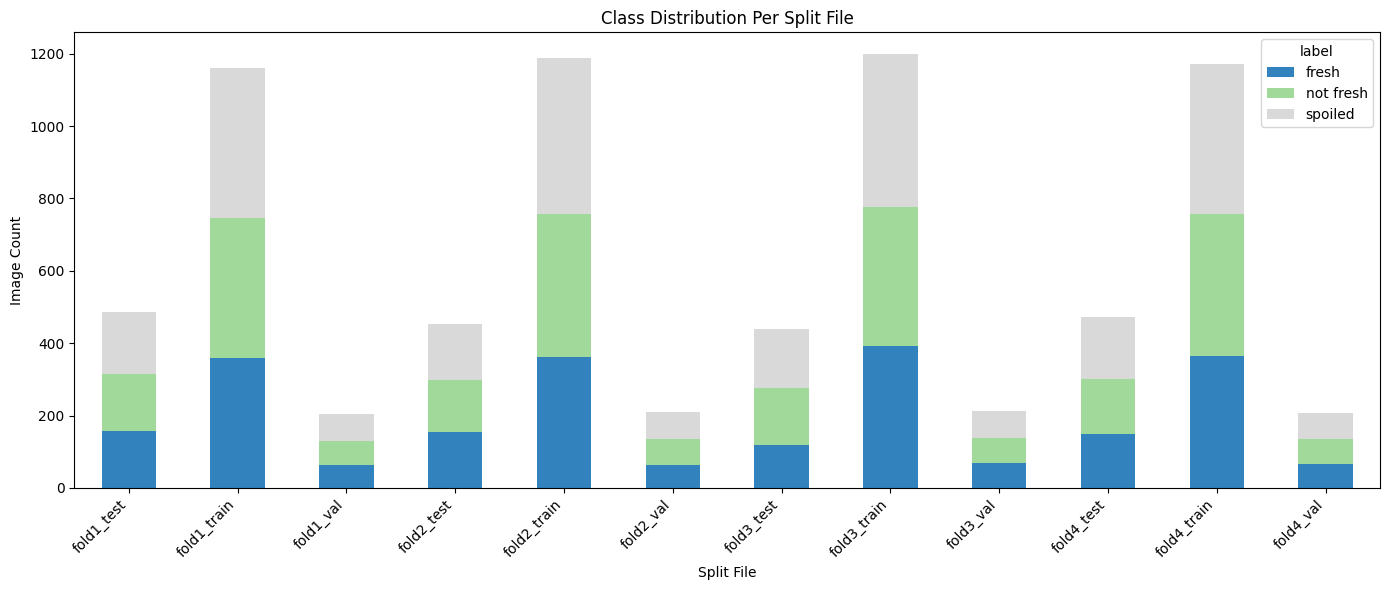

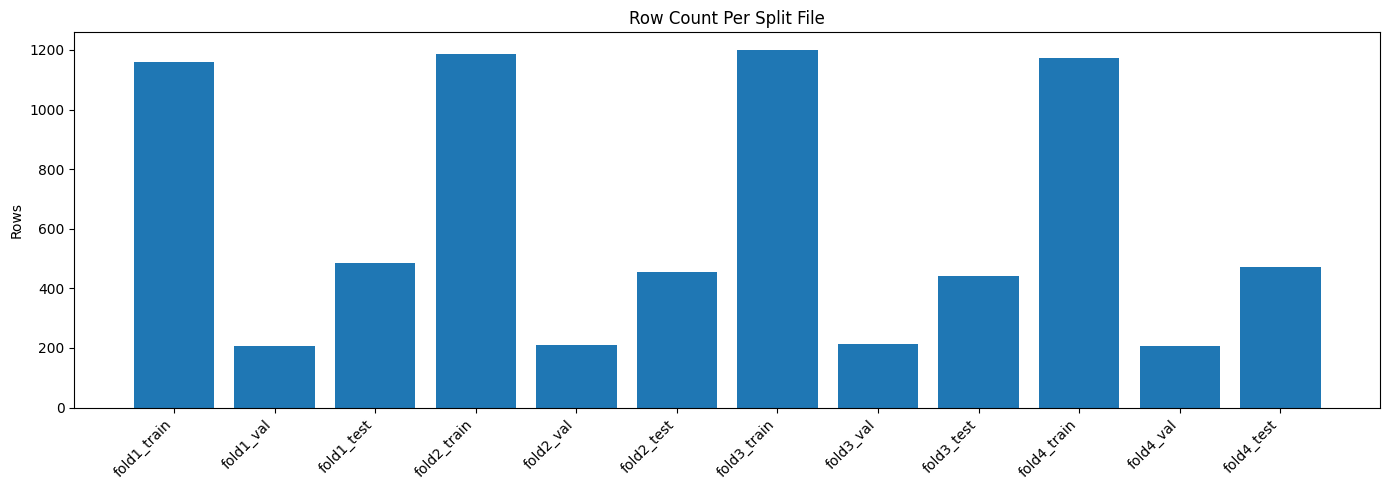

In [7]:
# ============================================================
# Split validation summaries and integrity checks
# ============================================================
validation_rows = []
missing_rows = []
integrity_rows = []

for split_key, info in SPLIT_DATA.items():
    df = info["df"]
    validation_rows.append(
        {
            "split_key": split_key,
            "split_mode": infer_split_type_from_key(split_key),
            "split_name": infer_fold_from_key(split_key),
            "split_part": infer_split_part_from_key(split_key),
            "row_count": int(len(df)),
            "missing_image_count": int(df["image_path_resolved"].isna().sum()),
            "label_distribution": json.dumps(df["label"].value_counts().to_dict()),
            "sample_id_distribution": json.dumps(df["sample_id"].value_counts().to_dict()),
            "sample_number_distribution": json.dumps(df["sample_number"].value_counts().to_dict()) if "sample_number" in df.columns else json.dumps({}),
            "pork_cut_distribution": json.dumps(df["pork_cut"].value_counts().to_dict()),
        }
    )

    for example_path in info["missing_examples"]:
        missing_rows.append(
            {
                "split_key": split_key,
                "csv_path": str(info["csv_path"]),
                "missing_example_path": example_path,
            }
        )

for fold_name, expected in EXPECTED_CROSS_HOLDOUTS.items():
    train_key = f"{fold_name}_train"
    val_key = f"{fold_name}_val"
    test_key = f"{fold_name}_test"
    if not all(k in SPLIT_DATA for k in [train_key, val_key, test_key]):
        continue

    held_out_sample = expected["held_out_sample"]
    train_df = SPLIT_DATA[train_key]["df"]
    val_df = SPLIT_DATA[val_key]["df"]
    test_df = SPLIT_DATA[test_key]["df"]

    in_train = held_out_sample in set(train_df["sample_id"].astype(str))
    in_val = held_out_sample in set(val_df["sample_id"].astype(str))
    in_test = held_out_sample in set(test_df["sample_id"].astype(str))

    integrity_rows.append(
        {
            "fold": fold_name,
            "held_out_sample": held_out_sample,
            "held_out_cut": expected["held_out_cut"],
            "held_out_absent_from_train": bool(not in_train),
            "held_out_absent_from_val": bool(not in_val),
            "held_out_present_in_test": bool(in_test),
            "status": "PASS" if ((not in_train) and (not in_val) and in_test) else "FAIL",
        }
    )

split_validation_summary_df = pd.DataFrame(validation_rows)
missing_images_summary_df = pd.DataFrame(missing_rows)
cross_rotation_integrity_df = pd.DataFrame(integrity_rows)

split_validation_summary_df.to_csv(TRAINING_OUTPUTS / "split_validation_summary.csv", index=False)
missing_images_summary_df.to_csv(TRAINING_OUTPUTS / "missing_images_summary.csv", index=False)
cross_rotation_integrity_df.to_csv(TRAINING_OUTPUTS / "cross_rotation_integrity.csv", index=False)

print(f"Saved: {TRAINING_OUTPUTS / 'split_validation_summary.csv'}")
print(f"Saved: {TRAINING_OUTPUTS / 'missing_images_summary.csv'}")
print(f"Saved: {TRAINING_OUTPUTS / 'cross_rotation_integrity.csv'}")

display(split_validation_summary_df)
display(cross_rotation_integrity_df)

def _counts_from_json_series(series):
    rows = []
    for _, row in series.iterrows():
        counts = json.loads(row["label_distribution"])
        for label_name in LABEL_ORDER:
            rows.append(
                {
                    "split_key": row["split_key"],
                    "label": label_name,
                    "count": int(counts.get(label_name, 0)),
                }
            )
    return pd.DataFrame(rows)

label_plot_df = _counts_from_json_series(split_validation_summary_df)
if len(label_plot_df) > 0:
    plt.figure(figsize=(14, 6))
    pivot = label_plot_df.pivot(index="split_key", columns="label", values="count").fillna(0)
    pivot = pivot[LABEL_ORDER]
    pivot.plot(kind="bar", stacked=True, figsize=(14, 6), colormap="tab20c")
    plt.title("Class Distribution Per Split File")
    plt.ylabel("Image Count")
    plt.xlabel("Split File")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "class_distribution_per_split.png", dpi=200)
    plt.show()

if len(split_validation_summary_df) > 0:
    plt.figure(figsize=(14, 5))
    plt.bar(split_validation_summary_df["split_key"], split_validation_summary_df["row_count"])
    plt.title("Row Count Per Split File")
    plt.ylabel("Rows")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "row_count_per_split.png", dpi=200)
    plt.show()


In [8]:
# ============================================================
# Deterministic preprocessing for full-image inputs
# ============================================================
def preprocess_resize(img: Image.Image, target_size=(224, 224)):
    return img.resize(target_size, Image.BILINEAR)


def preprocess_resize_pad(img: Image.Image, target_size=(224, 224), fill=(0, 0, 0)):
    canvas = Image.new("RGB", target_size, fill)
    copy = img.copy()
    copy.thumbnail(target_size, Image.BILINEAR)
    off_x = (target_size[0] - copy.size[0]) // 2
    off_y = (target_size[1] - copy.size[1]) // 2
    canvas.paste(copy, (off_x, off_y))
    return canvas


def preprocess_center_crop(img: Image.Image, target_size=(224, 224)):
    w, h = img.size
    side = min(w, h)
    left = (w - side) // 2
    top = (h - side) // 2
    crop = img.crop((left, top, left + side, top + side))
    return crop.resize(target_size, Image.BILINEAR)


def extract_roi_box_from_row(row):
    if row is None:
        return None

    if hasattr(row, "to_dict"):
        row_dict = row.to_dict()
    elif isinstance(row, dict):
        row_dict = row
    else:
        row_dict = dict(row)

    for cols in ROI_COLUMN_GROUPS:
        if all(col in row_dict for col in cols):
            vals = [row_dict.get(col) for col in cols]
            if any(pd.isna(v) for v in vals):
                continue

            if cols[2] in ["w", "bbox_w"]:
                x, y, w, h = [float(v) for v in vals]
                return (x, y, x + w, y + h)
            return tuple(float(v) for v in vals)
    return None


def preprocess_roi_crop(img: Image.Image, row=None, target_size=(224, 224)):
    box = extract_roi_box_from_row(row)
    if box is None:
        return preprocess_resize_pad(img, target_size=target_size)

    w, h = img.size
    xmin, ymin, xmax, ymax = box
    xmin = max(0, min(w - 1, int(round(xmin))))
    ymin = max(0, min(h - 1, int(round(ymin))))
    xmax = max(xmin + 1, min(w, int(round(xmax))))
    ymax = max(ymin + 1, min(h, int(round(ymax))))
    roi = img.crop((xmin, ymin, xmax, ymax))
    return roi.resize(target_size, Image.BILINEAR)


def load_image_for_model(path, image_crop_mode="center_crop", target_size=(224, 224), row=None):
    if path is None:
        raise ValueError("Image path is None")

    img = Image.open(path).convert("RGB")
    original_np = np.array(img)

    mode = str(image_crop_mode).lower().strip()
    if mode == "resize":
        proc = preprocess_resize(img, target_size)
    elif mode == "resize_pad":
        proc = preprocess_resize_pad(img, target_size)
    elif mode == "center_crop":
        proc = preprocess_center_crop(img, target_size)
    elif mode == "roi_crop":
        proc = preprocess_roi_crop(img, row=row, target_size=target_size)
    else:
        raise ValueError(f"Unsupported IMAGE_CROP_MODE: {image_crop_mode}")

    proc_np = np.asarray(proc).astype(np.float32) / 255.0
    return proc_np, original_np

print("Preprocessing functions ready.")
print("Default thesis preprocessing mode:", IMAGE_CROP_MODE)


Preprocessing functions ready.
Default thesis preprocessing mode: center_crop


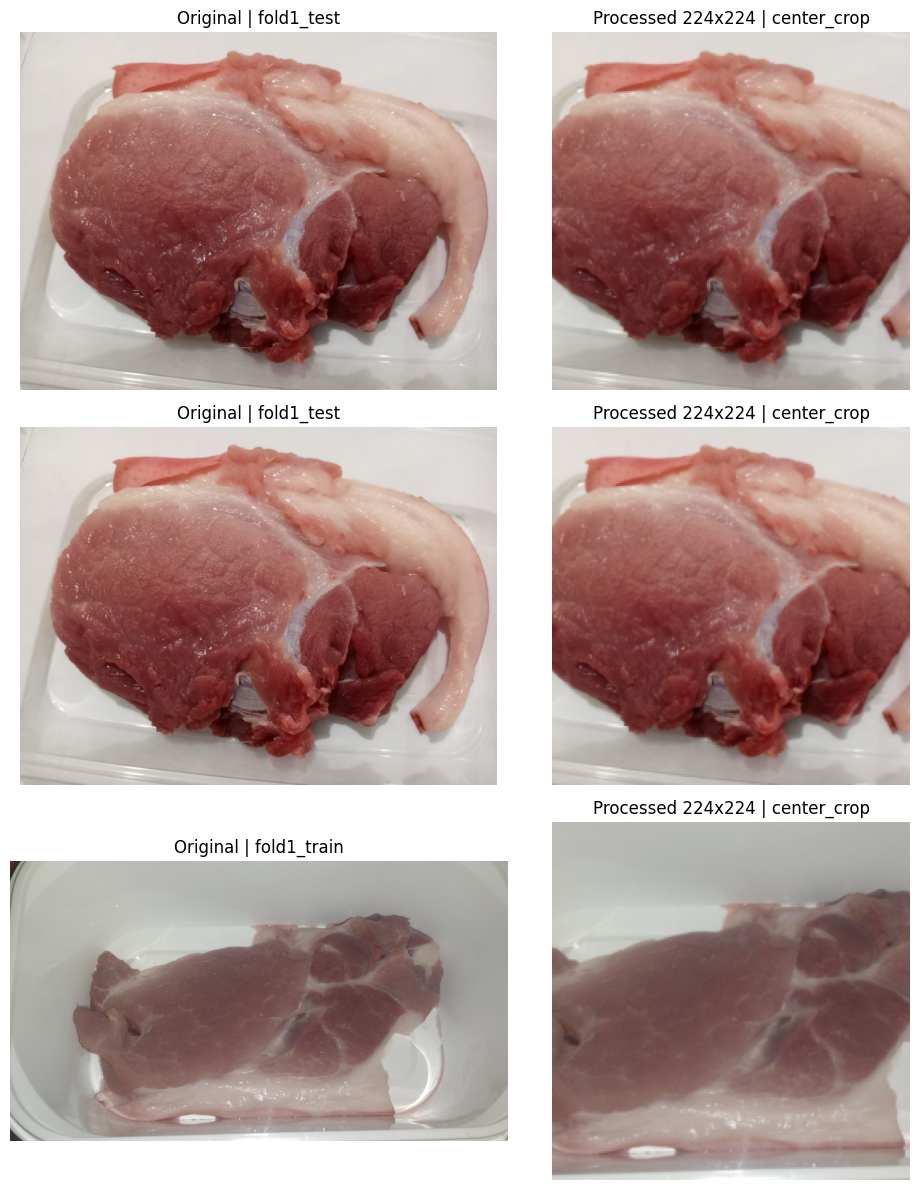

In [9]:
# ============================================================
# Example preprocessing visualization
# ============================================================
examples = []
for split_key in sorted(CLEAN_SPLIT_DATA.keys()):
    df = CLEAN_SPLIT_DATA[split_key]
    if len(df) == 0:
        continue
    for _, row in df.head(2).iterrows():
        examples.append((split_key, row))
        if len(examples) >= 3:
            break
    if len(examples) >= 3:
        break

if len(examples) == 0:
    print("No valid images found for preprocessing visualization.")
else:
    fig, axes = plt.subplots(len(examples), 2, figsize=(10, 4 * len(examples)))
    if len(examples) == 1:
        axes = np.array([axes])

    for i, (split_key, row) in enumerate(examples):
        proc, orig = load_image_for_model(
            path=row["image_path_resolved"],
            image_crop_mode=IMAGE_CROP_MODE,
            target_size=TARGET_SIZE,
            row=row,
        )
        axes[i, 0].imshow(orig)
        axes[i, 0].set_title(f"Original | {split_key}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(proc)
        axes[i, 1].set_title(f"Processed 224x224 | {IMAGE_CROP_MODE}")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "preprocessing_examples.png", dpi=200)
    plt.show()


In [10]:
# ============================================================
# Backbone registry, augmentation, and tf.data dataset builder
# ============================================================
BACKBONE_REGISTRY = {
    "MobileNetV3Small": {
        "constructor": MobileNetV3Small if TF_AVAILABLE else None,
        "preprocess_fn": preprocess_mobilenetv3 if TF_AVAILABLE else None,
        "preprocess_name": "mobilenet_v3.preprocess_input",
        "slug": "mobilenetv3small",
    },
    "EfficientNetB0": {
        "constructor": EfficientNetB0 if TF_AVAILABLE else None,
        "preprocess_fn": preprocess_efficientnetb0 if TF_AVAILABLE else None,
        "preprocess_name": "efficientnet.preprocess_input",
        "slug": "efficientnetb0",
    },
    "ResNet50": {
        "constructor": ResNet50 if TF_AVAILABLE else None,
        "preprocess_fn": preprocess_resnet50 if TF_AVAILABLE else None,
        "preprocess_name": "resnet50.preprocess_input",
        "slug": "resnet50",
    },
    "MobileNetV2": {
        "constructor": MobileNetV2 if TF_AVAILABLE else None,
        "preprocess_fn": preprocess_mobilenetv2 if TF_AVAILABLE else None,
        "preprocess_name": "mobilenet_v2.preprocess_input",
        "slug": "mobilenetv2",
    },
}


def _depthwise_filter_rgb(img, kernel_2d):
    kernel = tf.constant(kernel_2d, dtype=tf.float32)
    kernel = tf.reshape(kernel, [3, 3, 1, 1])
    kernel = tf.repeat(kernel, repeats=3, axis=2)
    x = tf.expand_dims(img, axis=0)
    y = tf.nn.depthwise_conv2d(x, kernel, strides=[1, 1, 1, 1], padding="SAME")
    return tf.squeeze(y, axis=0)


def _apply_mild_augmentation_tf(img):
    img = tf.clip_by_value(img, 0.0, 1.0)

    # Slight brightness and contrast changes
    img = tf.image.adjust_brightness(img, delta=tf.random.uniform([], -0.04, 0.04))
    contrast_factor = tf.random.uniform([], 0.95, 1.05)
    img = tf.image.adjust_contrast(img, contrast_factor)

    # Horizontal flip with p = 0.30
    img = tf.cond(
        tf.random.uniform([]) < 0.30,
        lambda: tf.image.flip_left_right(img),
        lambda: img,
    )

    # Mild blur / sharpen with p = 0.20 using a 0.90 original + 0.10 filtered blend
    def _blend_filtered():
        blur_kernel = [
            [1.0 / 9.0, 1.0 / 9.0, 1.0 / 9.0],
            [1.0 / 9.0, 1.0 / 9.0, 1.0 / 9.0],
            [1.0 / 9.0, 1.0 / 9.0, 1.0 / 9.0],
        ]
        filtered = tf.cond(
            tf.random.uniform([]) < 0.50,
            lambda: _depthwise_filter_rgb(img, SHARPEN_KERNEL),
            lambda: _depthwise_filter_rgb(img, blur_kernel),
        )
        return tf.clip_by_value((0.90 * img) + (0.10 * filtered), 0.0, 1.0)

    img = tf.cond(
        tf.random.uniform([]) < 0.20,
        _blend_filtered,
        lambda: img,
    )

    # Gaussian noise with p = 0.30
    def _add_noise():
        noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.01, dtype=tf.float32)
        return tf.clip_by_value(img + noise, 0.0, 1.0)

    img = tf.cond(
        tf.random.uniform([]) < 0.30,
        _add_noise,
        lambda: img,
    )

    return img


def _extract_label_index(df: pd.DataFrame):
    y = df["label"].map(LABEL_TO_INDEX)
    if y.isna().any():
        bad = df.loc[y.isna(), "label"].unique().tolist()
        raise ValueError(f"Unknown labels found: {bad}")
    return y.astype(np.int32).values


def make_cnn_dataset(
    df,
    backbone_name="MobileNetV2",
    training=False,
    batch_size=32,
    image_crop_mode="center_crop",
    target_size=(224, 224),
    seed=42,
):
    if not TF_AVAILABLE:
        raise RuntimeError("TensorFlow is not available.")

    if backbone_name not in BACKBONE_REGISTRY:
        raise ValueError(f"Unsupported backbone: {backbone_name}")

    preprocess_fn = BACKBONE_REGISTRY[backbone_name]["preprocess_fn"]
    work = df.copy()
    work = work.loc[~work["image_path_resolved"].isna()].reset_index(drop=True)
    work["label_idx"] = work["label"].map(LABEL_TO_INDEX).astype(np.int32)

    for col in ROI_ALL_COLUMNS:
        if col not in work.columns:
            work[col] = np.nan

    if len(work) == 0:
        raise ValueError("No valid images after path resolution.")

    paths = work["image_path_resolved"].astype(str).values
    labels = work["label_idx"].astype(np.int32).values
    bbox_matrix = work[ROI_ALL_COLUMNS].astype(np.float32).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels, bbox_matrix))
    if training:
        ds = ds.shuffle(buffer_size=len(work), seed=seed, reshuffle_each_iteration=True)

    def _py_loader(path_tensor, bbox_tensor):
        path = path_tensor.numpy().decode("utf-8")
        bbox_vals = bbox_tensor.numpy().tolist()
        row = {}
        for col_name, val in zip(ROI_ALL_COLUMNS, bbox_vals):
            row[col_name] = None if pd.isna(val) else float(val)
        proc, _ = load_image_for_model(
            path=path,
            image_crop_mode=image_crop_mode,
            target_size=target_size,
            row=row,
        )
        return proc.astype(np.float32)

    def _map_fn(path_tensor, label_tensor, bbox_tensor):
        image = tf.py_function(
            func=_py_loader,
            inp=[path_tensor, bbox_tensor],
            Tout=tf.float32,
        )
        image.set_shape((target_size[0], target_size[1], 3))
        if training:
            image = _apply_mild_augmentation_tf(image)
        image = preprocess_fn(image * 255.0)
        return image, tf.cast(label_tensor, tf.int32)

    options = tf.data.Options()
    options.experimental_deterministic = not training
    ds = ds.with_options(options)
    ds = ds.map(_map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds, len(work), work


In [11]:
# ============================================================
# Model building, optimizer, callbacks, and two-phase training
# ============================================================
ADAMW_WARNING_PRINTED = False


def build_cnn_model(backbone_name="MobileNetV2", input_shape=(224, 224, 3), num_classes=3):
    if not TF_AVAILABLE:
        raise RuntimeError("TensorFlow is not available.")

    reg = BACKBONE_REGISTRY[backbone_name]
    backbone_ctor = reg["constructor"]
    backbone = backbone_ctor(include_top=False, weights="imagenet", input_shape=input_shape)
    backbone.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.20)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name=f"{backbone_name}_cnn_only")
    return model, backbone


def make_optimizer(lr, weight_decay=1e-4):
    global ADAMW_WARNING_PRINTED
    if hasattr(tf.keras.optimizers, "AdamW"):
        return tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay)
    if not ADAMW_WARNING_PRINTED:
        print("[WARN] AdamW is not available. Falling back to Adam.")
        ADAMW_WARNING_PRINTED = True
    return tf.keras.optimizers.Adam(learning_rate=lr)


def unfreeze_top_layers(backbone, fraction=0.20):
    backbone.trainable = True
    total_layers = len(backbone.layers)
    unfreeze_from = max(0, int(total_layers * (1.0 - fraction)))

    for idx, layer in enumerate(backbone.layers):
        if idx < unfreeze_from:
            layer.trainable = False
        else:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
            else:
                layer.trainable = True


class ValF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, val_ds):
        super().__init__()
        self.val_ds = val_ds

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        y_true = []
        y_pred = []
        for xb, yb in self.val_ds:
            probs = self.model.predict(xb, verbose=0)
            pred = np.argmax(probs, axis=1)
            y_true.extend(yb.numpy().tolist())
            y_pred.extend(pred.tolist())

        _, _, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="macro", zero_division=0
        )
        logs["val_f1_macro"] = float(f1)


class TrainingProgressLogger(tf.keras.callbacks.Callback):
    def __init__(self, run_context, phase_name):
        super().__init__()
        self.run_context = run_context
        self.phase_name = phase_name

    def on_train_begin(self, logs=None):
        print("\n============================================================")
        print("Training run started")
        print(f"split mode      : {self.run_context.get('split_mode')}")
        print(f"split name      : {self.run_context.get('split_name')}")
        print(f"held-out sample : {self.run_context.get('held_out_sample')}")
        print(f"held-out cut    : {self.run_context.get('held_out_cut')}")
        print(f"backbone        : {self.run_context.get('backbone_name')}")
        print(f"seed            : {self.run_context.get('seed')}")
        print(f"train count     : {self.run_context.get('train_count')}")
        print(f"validation count: {self.run_context.get('val_count')}")
        print(f"test count      : {self.run_context.get('test_count')}")
        print(f"class weights   : {self.run_context.get('class_weights')}")
        print(f"current phase   : {self.phase_name}")
        print("============================================================")

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        lr = self.model.optimizer.learning_rate
        lr_value = float(tf.keras.backend.get_value(lr))
        msg = (
            f"[{self.phase_name}] "
            f"epoch={epoch + 1:02d} "
            f"loss={logs.get('loss', np.nan):.4f} "
            f"acc={logs.get('accuracy', np.nan):.4f} "
            f"val_loss={logs.get('val_loss', np.nan):.4f} "
            f"val_acc={logs.get('val_accuracy', np.nan):.4f} "
            f"val_f1_macro={logs.get('val_f1_macro', np.nan):.4f} "
            f"lr={lr_value:.8f}"
        )
        print(msg)


def build_phase_callbacks(val_ds, checkpoint_path, run_context, phase_name):
    return [
        ValF1Callback(val_ds),
        TrainingProgressLogger(run_context=run_context, phase_name=phase_name),
        EarlyStopping(
            monitor="val_f1_macro",
            mode="max",
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_f1_macro",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            verbose=1,
        ),
    ]


def train_two_phase_cnn(
    model,
    backbone,
    train_ds,
    val_ds,
    class_weight=None,
    backbone_name="MobileNetV2",
    run_name="run",
    run_context=None,
):
    if not TF_AVAILABLE:
        raise RuntimeError("TensorFlow is not available.")

    checkpoints_dir = MODELS_DIR / "checkpoints"
    checkpoints_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = checkpoints_dir / f"{run_name}_best.weights.h5"

    model.compile(
        optimizer=make_optimizer(HEAD_LR, weight_decay=WEIGHT_DECAY),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    history_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_HEAD,
        class_weight=class_weight,
        callbacks=build_phase_callbacks(val_ds, checkpoint_path, run_context, phase_name="head training"),
        verbose=1,
    )

    if checkpoint_path.exists():
        model.load_weights(checkpoint_path)
        print(f"[INFO] Loaded best weights after head training: {checkpoint_path}")

    unfreeze_top_layers(backbone, fraction=FINE_TUNE_FRACTION[backbone_name])
    fine_lr = FINE_TUNE_LR.get(backbone_name, 1e-5)
    model.compile(
        optimizer=make_optimizer(fine_lr, weight_decay=WEIGHT_DECAY),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    history_fine = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FINE,
        class_weight=class_weight,
        callbacks=build_phase_callbacks(val_ds, checkpoint_path, run_context, phase_name="fine-tuning"),
        verbose=1,
    )

    if checkpoint_path.exists():
        model.load_weights(checkpoint_path)
        print(f"[INFO] Loaded best weights after fine-tuning: {checkpoint_path}")

    history = {
        "head": history_head.history,
        "fine": history_fine.history,
        "best_checkpoint": str(checkpoint_path),
    }
    return model, history


In [12]:
# ============================================================
# Plot helpers, evaluation, speed, size, and scoring
# ============================================================
def _history_to_df(history_dict):
    rows = []
    global_epoch = 0
    for phase_name in ["head", "fine"]:
        phase_hist = history_dict.get(phase_name, {})
        epochs = max((len(v) for v in phase_hist.values()), default=0)
        for i in range(epochs):
            row = {"phase": phase_name, "epoch_in_phase": i + 1, "epoch_global": global_epoch + 1}
            for metric_name, values in phase_hist.items():
                row[metric_name] = values[i]
            rows.append(row)
            global_epoch += 1
    return pd.DataFrame(rows)


def plot_training_history(history_dict, run_stem, show_inline=True):
    hist_df = _history_to_df(history_dict)
    if len(hist_df) == 0:
        return hist_df

    def _save_line(y_cols, title, ylabel, filename):
        plt.figure(figsize=(7, 4))
        for col in y_cols:
            if col in hist_df.columns:
                plt.plot(hist_df["epoch_global"], hist_df[col], marker="o", label=col)
        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / filename, dpi=200)
        if show_inline:
            plt.show()
        else:
            plt.close()

    _save_line(
        ["loss", "val_loss"],
        f"Training Loss vs Validation Loss\n{run_stem}",
        "Loss",
        f"{run_stem}_training_loss.png",
    )
    _save_line(
        ["accuracy", "val_accuracy"],
        f"Training Accuracy vs Validation Accuracy\n{run_stem}",
        "Accuracy",
        f"{run_stem}_training_accuracy.png",
    )
    _save_line(
        ["val_f1_macro"],
        f"Validation Macro F1\n{run_stem}",
        "Macro F1",
        f"{run_stem}_validation_macro_f1.png",
    )

    lr_col = "learning_rate" if "learning_rate" in hist_df.columns else ("lr" if "lr" in hist_df.columns else None)
    if lr_col is not None:
        _save_line(
            [lr_col],
            f"Learning Rate by Epoch\n{run_stem}",
            "Learning Rate",
            f"{run_stem}_learning_rate.png",
        )

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    axes[0].plot(hist_df["epoch_global"], hist_df.get("loss"), marker="o", label="loss")
    axes[0].plot(hist_df["epoch_global"], hist_df.get("val_loss"), marker="o", label="val_loss")
    axes[0].set_title("Loss")
    axes[0].legend()

    axes[1].plot(hist_df["epoch_global"], hist_df.get("accuracy"), marker="o", label="accuracy")
    axes[1].plot(hist_df["epoch_global"], hist_df.get("val_accuracy"), marker="o", label="val_accuracy")
    axes[1].set_title("Accuracy")
    axes[1].legend()

    if "val_f1_macro" in hist_df.columns:
        axes[2].plot(hist_df["epoch_global"], hist_df["val_f1_macro"], marker="o", label="val_f1_macro")
        axes[2].legend()
    axes[2].set_title("Validation Macro F1")

    if lr_col is not None:
        axes[3].plot(hist_df["epoch_global"], hist_df[lr_col], marker="o", label=lr_col)
        axes[3].legend()
    axes[3].set_title("Learning Rate")

    for ax in axes:
        ax.set_xlabel("Epoch")

    fig.suptitle(run_stem)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{run_stem}_training_history_combined.png", dpi=200)
    if show_inline:
        plt.show()
    else:
        plt.close(fig)

    return hist_df


def plot_confusion_matrices(cm, cm_norm, run_stem, show_inline=True):
    def _plot_one(mat, title, cmap, out_name, fmt=".2f"):
        fig, ax = plt.subplots(figsize=(5, 4))
        if SEABORN_AVAILABLE:
            sns.heatmap(
                mat,
                annot=True,
                fmt=fmt,
                cmap=cmap,
                xticklabels=LABEL_ORDER,
                yticklabels=LABEL_ORDER,
                ax=ax,
            )
        else:
            ax.imshow(mat, cmap=cmap)
            ax.set_xticks(range(len(LABEL_ORDER)))
            ax.set_yticks(range(len(LABEL_ORDER)))
            ax.set_xticklabels(LABEL_ORDER, rotation=30)
            ax.set_yticklabels(LABEL_ORDER)
            for i in range(len(LABEL_ORDER)):
                for j in range(len(LABEL_ORDER)):
                    ax.text(j, i, f"{mat[i, j]:{fmt}}", ha="center", va="center")
        ax.set_title(title)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / out_name, dpi=200)
        if show_inline:
            plt.show()
        else:
            plt.close(fig)

    _plot_one(cm, f"Confusion Matrix\n{run_stem}", "Blues", f"{run_stem}_confusion_matrix.png", fmt=".0f")
    _plot_one(
        cm_norm,
        f"Normalized Confusion Matrix\n{run_stem}",
        "Oranges",
        f"{run_stem}_normalized_confusion_matrix.png",
        fmt=".2f",
    )


def plot_prediction_distribution(pred_distribution, run_stem, show_inline=True):
    values = [int(pred_distribution.get(label_name, 0)) for label_name in LABEL_ORDER]
    plt.figure(figsize=(6, 4))
    bars = plt.bar(LABEL_ORDER, values, color=["#7fc97f", "#fdc086", "#f0027f"])
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width() / 2, value, str(value), ha="center", va="bottom")
    plt.title(f"Prediction Distribution\n{run_stem}")
    plt.ylabel("Predicted Count")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{run_stem}_prediction_distribution.png", dpi=200)
    if show_inline:
        plt.show()
    else:
        plt.close()


def evaluate_cnn_model(model, test_ds, split_name="unknown", backbone_name="unknown", run_stem="run", show_plots=True):
    y_true = []
    y_pred = []
    y_prob = []

    for xb, yb in test_ds:
        probs = model.predict(xb, verbose=0)
        pred = np.argmax(probs, axis=1)
        y_true.extend(yb.numpy().tolist())
        y_pred.extend(pred.tolist())
        y_prob.extend(probs.tolist())

    y_true = np.array(y_true, dtype=np.int32)
    y_pred = np.array(y_pred, dtype=np.int32)
    y_prob = np.array(y_prob, dtype=np.float32)

    accuracy = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    cls_report = classification_report(
        y_true,
        y_pred,
        target_names=LABEL_ORDER,
        output_dict=True,
        zero_division=0,
    )
    pred_distribution = pd.Series(y_pred).map(INDEX_TO_LABEL).value_counts().to_dict()

    if show_plots:
        plot_confusion_matrices(cm, cm_norm, run_stem=run_stem, show_inline=True)
        plot_prediction_distribution(pred_distribution, run_stem=run_stem, show_inline=True)

    return {
        "accuracy": float(accuracy),
        "macro_precision": float(precision_macro),
        "macro_recall": float(recall_macro),
        "macro_f1": float(f1_macro),
        "confusion_matrix": cm.tolist(),
        "normalized_confusion_matrix": cm_norm.tolist(),
        "classification_report": cls_report,
        "prediction_distribution": pred_distribution,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }


def measure_inference_speed(model, df, backbone_name="MobileNetV2", sample_size=50, seed=42):
    work = df.loc[~df["image_path_resolved"].isna()].copy()
    if len(work) == 0:
        return np.nan, np.nan

    sample_n = min(sample_size, len(work))
    sample_df = work.sample(n=sample_n, random_state=seed).reset_index(drop=True)
    preprocess_fn = BACKBONE_REGISTRY[backbone_name]["preprocess_fn"]

    def _prepare_one(row):
        proc, _ = load_image_for_model(
            row["image_path_resolved"],
            image_crop_mode=IMAGE_CROP_MODE,
            target_size=TARGET_SIZE,
            row=row,
        )
        arr = preprocess_fn(proc * 255.0)
        return np.expand_dims(arr.astype(np.float32), axis=0)

    for i in range(min(5, sample_n)):
        x = _prepare_one(sample_df.iloc[i])
        _ = model.predict(x, verbose=0)

    times_ms = []
    for i in range(sample_n):
        x = _prepare_one(sample_df.iloc[i])
        t0 = time.perf_counter()
        _ = model.predict(x, verbose=0)
        dt = (time.perf_counter() - t0) * 1000.0
        times_ms.append(dt)

    return float(np.mean(times_ms)), float(np.std(times_ms))


def measure_model_size_mb(path):
    p = Path(path)
    if not p.exists():
        return np.nan
    return float(p.stat().st_size / (1024 ** 2))


def export_tflite(model, output_path):
    try:
        converter = tf.lite.TFLiteConverter.from_keras_model(model)
        tflite_model = converter.convert()
        with open(output_path, "wb") as f:
            f.write(tflite_model)
        return True
    except Exception as e:
        print(f"[WARN] TFLite export failed for {output_path}: {e}")
        return False


def freshness_score(predicted_class, confidence):
    confidence = float(np.clip(confidence, 0.0, 1.0))
    if predicted_class == "fresh":
        return float(70 + (30 * confidence))
    if predicted_class == "not fresh":
        return float(40 + (20 * confidence))
    return float(max(0.0, 39 - (34 * confidence)))


def recommendation_from_score(score):
    if score >= 70:
        return "Good for Consumption"
    if score >= 40:
        return "Consume Immediately"
    return "Not Suitable"


In [14]:
# ============================================================
# Experiment runner helpers
# ============================================================
def _get_split_triplet(split_mode="cross_rotation", split_name="fold1"):
    if split_mode == "cross_rotation":
        train_key = f"{split_name}_train"
        val_key = f"{split_name}_val"
        test_key = f"{split_name}_test"
    elif split_mode == "random_70_15_15":
        train_key = "random_train"
        val_key = "random_val"
        test_key = "random_test"
    else:
        raise ValueError("split_mode must be 'cross_rotation' or 'random_70_15_15'")

    for key in [train_key, val_key, test_key]:
        if key not in CLEAN_SPLIT_DATA:
            raise KeyError(f"Missing cleaned split dataframe: {key}")
    return train_key, val_key, test_key


def _compute_class_weights_from_df(df):
    y = df["label"].map(LABEL_TO_INDEX).astype(np.int32).values
    classes = np.array([0, 1, 2], dtype=np.int32)
    cw = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return {int(c): float(w) for c, w in zip(classes, cw)}


def _get_held_out_info(split_mode, split_name, test_df):
    if split_mode == "cross_rotation":
        expected = EXPECTED_CROSS_HOLDOUTS.get(split_name, {})
        held_out_sample = expected.get("held_out_sample")
        held_out_cut = expected.get("held_out_cut")
    else:
        held_out_sample = None
        held_out_cut = None

    if held_out_sample is None and "sample_id" in test_df.columns:
        uniq = sorted(test_df["sample_id"].astype(str).unique().tolist())
        held_out_sample = "|".join(uniq)

    if held_out_cut is None and "pork_cut" in test_df.columns:
        uniq_cut = sorted(test_df["pork_cut"].astype(str).unique().tolist())
        held_out_cut = "|".join(uniq_cut)

    return held_out_sample, held_out_cut


def _make_run_stem(backbone_name, split_mode, split_name, seed):
    slug = BACKBONE_REGISTRY[backbone_name]["slug"]
    return f"meatlens_{slug}_{split_mode}_{split_name}_seed{seed}_cnn_only"


def _save_json(path, payload):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)


def run_single_cnn_experiment(split_mode="cross_rotation", split_name="fold1", backbone_name="MobileNetV2", seed=42):
    if not TF_AVAILABLE:
        raise RuntimeError("TensorFlow is required.")

    set_global_seed(seed)

    train_key, val_key, test_key = _get_split_triplet(split_mode=split_mode, split_name=split_name)
    train_df = CLEAN_SPLIT_DATA[train_key].copy()
    val_df = CLEAN_SPLIT_DATA[val_key].copy()
    test_df = CLEAN_SPLIT_DATA[test_key].copy()

    held_out_sample, held_out_cut = _get_held_out_info(split_mode, split_name, test_df)
    class_weights = _compute_class_weights_from_df(train_df)

    train_ds, n_train, train_used = make_cnn_dataset(
        train_df,
        backbone_name=backbone_name,
        training=True,
        batch_size=BATCH_SIZE,
        image_crop_mode=IMAGE_CROP_MODE,
        target_size=TARGET_SIZE,
        seed=seed,
    )
    val_ds, n_val, val_used = make_cnn_dataset(
        val_df,
        backbone_name=backbone_name,
        training=False,
        batch_size=BATCH_SIZE,
        image_crop_mode=IMAGE_CROP_MODE,
        target_size=TARGET_SIZE,
        seed=seed,
    )
    test_ds, n_test, test_used = make_cnn_dataset(
        test_df,
        backbone_name=backbone_name,
        training=False,
        batch_size=BATCH_SIZE,
        image_crop_mode=IMAGE_CROP_MODE,
        target_size=TARGET_SIZE,
        seed=seed,
    )

    run_stem = _make_run_stem(backbone_name, split_mode, split_name, seed)
    run_context = {
        "split_mode": split_mode,
        "split_name": split_name,
        "held_out_sample": held_out_sample,
        "held_out_cut": held_out_cut,
        "backbone_name": backbone_name,
        "seed": seed,
        "train_count": n_train,
        "val_count": n_val,
        "test_count": n_test,
        "class_weights": class_weights,
    }

    model, backbone = build_cnn_model(
        backbone_name=backbone_name,
        input_shape=INPUT_SHAPE,
        num_classes=NUM_CLASSES,
    )
    model, history = train_two_phase_cnn(
        model=model,
        backbone=backbone,
        train_ds=train_ds,
        val_ds=val_ds,
        class_weight=class_weights,
        backbone_name=backbone_name,
        run_name=run_stem,
        run_context=run_context,
    )

    history_df = plot_training_history(history, run_stem=run_stem, show_inline=True)
    eval_res = evaluate_cnn_model(
        model=model,
        test_ds=test_ds,
        split_name=split_name,
        backbone_name=backbone_name,
        run_stem=run_stem,
        show_plots=True,
    )

    model_h5_path = MODELS_DIR / f"{run_stem}.h5"
    model.save(model_h5_path)

    model_tflite_path = MODELS_DIR / f"{run_stem}.tflite"
    export_tflite(model, model_tflite_path)

    model_metadata_path = MODELS_DIR / f"{run_stem}_metadata.json"
    metadata = {
        "backbone": backbone_name,
        "preprocess_function_name": BACKBONE_REGISTRY[backbone_name]["preprocess_name"],
        "input_size": list(TARGET_SIZE),
        "image_crop_mode": IMAGE_CROP_MODE,
        "model_input_mode": MODEL_INPUT_MODE,
        "split_mode": split_mode,
        "split_name": split_name,
        "seed": seed,
        "label_order": LABEL_ORDER,
        "class_index_mapping": LABEL_TO_INDEX,
        "macro_f1": float(eval_res["macro_f1"]),
        "accuracy": float(eval_res["accuracy"]),
        "model_path": str(model_h5_path),
        "tflite_path": str(model_tflite_path),
        "timestamp": datetime.now().isoformat(),
    }
    _save_json(model_metadata_path, metadata)

    inference_mean_ms, inference_std_ms = measure_inference_speed(
        model=model,
        df=test_used,
        backbone_name=backbone_name,
        sample_size=50,
        seed=seed,
    )

    history_csv_path = TRAINING_OUTPUTS / f"{run_stem}_history.csv"
    history_df.to_csv(history_csv_path, index=False)

    result = {
        "run_stem": run_stem,
        "split_mode": split_mode,
        "split_name": split_name,
        "backbone": backbone_name,
        "seed": seed,
        "held_out_sample": held_out_sample,
        "held_out_cut": held_out_cut,
        "train_count": int(n_train),
        "val_count": int(n_val),
        "test_count": int(n_test),
        "class_weights": json.dumps(class_weights),
        "accuracy": float(eval_res["accuracy"]),
        "macro_precision": float(eval_res["macro_precision"]),
        "macro_recall": float(eval_res["macro_recall"]),
        "macro_f1": float(eval_res["macro_f1"]),
        "prediction_distribution": json.dumps(eval_res["prediction_distribution"]),
        "confusion_matrix": json.dumps(eval_res["confusion_matrix"]),
        "normalized_confusion_matrix": json.dumps(eval_res["normalized_confusion_matrix"]),
        "classification_report": json.dumps(eval_res["classification_report"]),
        "model_h5_path": str(model_h5_path),
        "model_tflite_path": str(model_tflite_path),
        "metadata_json_path": str(model_metadata_path),
        "history_csv_path": str(history_csv_path),
        "h5_size_mb": measure_model_size_mb(model_h5_path),
        "tflite_size_mb": measure_model_size_mb(model_tflite_path),
        "inference_mean_ms_per_image": inference_mean_ms,
        "inference_std_ms_per_image": inference_std_ms,
    }

    del model
    gc.collect()
    tf.keras.backend.clear_session()
    return result


In [15]:
# ============================================================
# Summary tables and thesis documentation plots
# ============================================================
def _prediction_distribution_df(seed_metrics_df):
    rows = []
    for _, row in seed_metrics_df.iterrows():
        dist = json.loads(row["prediction_distribution"])
        rows.append(
            {
                "run_stem": row["run_stem"],
                "split_mode": row["split_mode"],
                "split_name": row["split_name"],
                "backbone": row["backbone"],
                "seed": row["seed"],
                "pred_fresh": int(dist.get("fresh", 0)),
                "pred_not_fresh": int(dist.get("not fresh", 0)),
                "pred_spoiled": int(dist.get("spoiled", 0)),
            }
        )
    return pd.DataFrame(rows)


def _classification_report_df_from_row(row):
    report = json.loads(row["classification_report"])
    rows = []
    for class_name in LABEL_ORDER:
        if class_name in report:
            rows.append(
                {
                    "class_name": class_name,
                    "precision": report[class_name]["precision"],
                    "recall": report[class_name]["recall"],
                    "f1_score": report[class_name]["f1-score"],
                    "support": report[class_name]["support"],
                }
            )
    return pd.DataFrame(rows)


def plot_metrics_summary(fold_metrics_df, show_inline=True):
    if len(fold_metrics_df) == 0:
        print("No fold metrics available for plotting.")
        return

    cross_df = fold_metrics_df.loc[fold_metrics_df["split_mode"] == "cross_rotation"].copy()
    if len(cross_df) == 0:
        return

    plt.figure(figsize=(10, 5))
    for backbone_name, sub in cross_df.groupby("backbone"):
        plt.plot(sub["split_name"], sub["macro_f1_mean"], marker="o", label=backbone_name)
    plt.title("Cross-Rotation Macro F1 by Fold")
    plt.ylabel("Macro F1")
    plt.xlabel("Fold")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "cross_rotation_macro_f1_by_fold.png", dpi=200)
    if show_inline:
        plt.show()
    else:
        plt.close()

    plt.figure(figsize=(10, 5))
    for backbone_name, sub in cross_df.groupby("backbone"):
        plt.plot(sub["split_name"], sub["accuracy_mean"], marker="o", label=backbone_name)
    plt.title("Cross-Rotation Accuracy by Fold")
    plt.ylabel("Accuracy")
    plt.xlabel("Fold")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "cross_rotation_accuracy_by_fold.png", dpi=200)
    if show_inline:
        plt.show()
    else:
        plt.close()

    metric_cols = ["macro_precision_mean", "macro_recall_mean", "macro_f1_mean"]
    plot_df = cross_df.groupby("backbone")[metric_cols].mean().reset_index()
    plot_df = plot_df.rename(
        columns={
            "macro_precision_mean": "Macro Precision",
            "macro_recall_mean": "Macro Recall",
            "macro_f1_mean": "Macro F1",
        }
    )
    plot_df = plot_df.set_index("backbone")
    plot_df.plot(kind="bar", figsize=(10, 5))
    plt.title("Cross-Rotation Macro Precision / Recall / F1 Comparison")
    plt.ylabel("Score")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "cross_rotation_precision_recall_f1_comparison.png", dpi=200)
    if show_inline:
        plt.show()
    else:
        plt.close()


def plot_backbone_comparison(backbone_summary_df, show_inline=True):
    if len(backbone_summary_df) == 0:
        print("No backbone summary available for plotting.")
        return

    cross_df = backbone_summary_df.loc[backbone_summary_df["evaluation_group"] == "cross_rotation"].copy()
    if len(cross_df) > 0:
        plt.figure(figsize=(10, 5))
        ordered = cross_df.sort_values("macro_f1_mean", ascending=False)
        plt.bar(ordered["backbone"], ordered["macro_f1_mean"])
        plt.title("Backbone Comparison by Mean Macro F1")
        plt.ylabel("Mean Macro F1")
        plt.xticks(rotation=25)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "backbone_mean_f1_comparison.png", dpi=200)
        if show_inline:
            plt.show()
        else:
            plt.close()

        plt.figure(figsize=(10, 5))
        ordered = cross_df.sort_values("accuracy_mean", ascending=False)
        plt.bar(ordered["backbone"], ordered["accuracy_mean"])
        plt.title("Backbone Comparison by Accuracy")
        plt.ylabel("Mean Accuracy")
        plt.xticks(rotation=25)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "backbone_accuracy_comparison.png", dpi=200)
        if show_inline:
            plt.show()
        else:
            plt.close()


def plot_cut_performance(cut_performance_df, show_inline=True):
    if len(cut_performance_df) == 0:
        print("No cut performance data available for plotting.")
        return

    pivot = cut_performance_df.pivot(index="backbone", columns="held_out_cut", values="macro_f1_mean")
    pivot = pivot[[c for c in ["shoulder", "belly"] if c in pivot.columns]]
    pivot.plot(kind="bar", figsize=(10, 5))
    plt.title("Shoulder-Held-Out vs Belly-Held-Out Macro F1")
    plt.ylabel("Macro F1")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "shoulder_vs_belly_f1.png", dpi=200)
    if show_inline:
        plt.show()
    else:
        plt.close()


def plot_inference_speed(inference_speed_df, show_inline=True):
    if len(inference_speed_df) == 0:
        print("No inference speed data available for plotting.")
        return

    agg = (
        inference_speed_df.groupby("backbone", as_index=False)
        .agg(mean_ms=("inference_mean_ms_per_image", "mean"), std_ms=("inference_mean_ms_per_image", "std"))
        .sort_values("mean_ms")
    )
    plt.figure(figsize=(10, 5))
    plt.bar(agg["backbone"], agg["mean_ms"], yerr=agg["std_ms"].fillna(0.0))
    plt.title("Inference Speed Comparison")
    plt.ylabel("Milliseconds per Image")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "inference_speed_comparison.png", dpi=200)
    if show_inline:
        plt.show()
    else:
        plt.close()


def plot_model_size(model_size_df, show_inline=True):
    if len(model_size_df) == 0:
        print("No model size data available for plotting.")
        return

    agg = (
        model_size_df.groupby("backbone", as_index=False)
        .agg(h5_size_mb=("h5_size_mb", "mean"), tflite_size_mb=("tflite_size_mb", "mean"))
    )
    x = np.arange(len(agg))
    width = 0.35
    plt.figure(figsize=(10, 5))
    plt.bar(x - width / 2, agg["h5_size_mb"], width=width, label="H5")
    plt.bar(x + width / 2, agg["tflite_size_mb"], width=width, label="TFLite")
    plt.xticks(x, agg["backbone"], rotation=25)
    plt.ylabel("Model Size (MB)")
    plt.title("Model Size Comparison")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "model_size_comparison.png", dpi=200)
    if show_inline:
        plt.show()
    else:
        plt.close()


def _plot_random_vs_cross(backbone_summary_df, show_inline=True):
    if len(backbone_summary_df) == 0:
        return
    pivot = backbone_summary_df.pivot(index="backbone", columns="evaluation_group", values="macro_f1_mean")
    expected_cols = [c for c in ["cross_rotation", "random_70_15_15"] if c in pivot.columns]
    if len(expected_cols) == 0:
        return
    pivot = pivot[expected_cols]
    pivot.plot(kind="bar", figsize=(10, 5))
    plt.title("Random Baseline vs Cross-Rotation Macro F1")
    plt.ylabel("Mean Macro F1")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "random_vs_cross_rotation_f1.png", dpi=200)
    if show_inline:
        plt.show()
    else:
        plt.close()


def _plot_prediction_distribution_by_split(prediction_distribution_df, show_inline=True):
    if len(prediction_distribution_df) == 0:
        return
    tmp = prediction_distribution_df.copy()
    tmp["split_id"] = tmp["split_mode"] + ":" + tmp["split_name"] + ":" + tmp["backbone"]
    melt = tmp.melt(
        id_vars=["split_id"],
        value_vars=["pred_fresh", "pred_not_fresh", "pred_spoiled"],
        var_name="predicted_label",
        value_name="count",
    )
    pivot = melt.pivot(index="split_id", columns="predicted_label", values="count").fillna(0)
    pivot.plot(kind="bar", stacked=True, figsize=(14, 6))
    plt.title("Prediction Distribution Per Split")
    plt.ylabel("Predicted Count")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "prediction_distribution_per_split.png", dpi=200)
    if show_inline:
        plt.show()
    else:
        plt.close()


def _plot_best_model_per_class(best_model_report_df, show_inline=True):
    if len(best_model_report_df) == 0:
        return

    plt.figure(figsize=(8, 4))
    plt.bar(best_model_report_df["class_name"], best_model_report_df["f1_score"])
    plt.title("Per-Class F1-Score for Best Model")
    plt.ylabel("F1-Score")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "best_model_per_class_f1.png", dpi=200)
    if show_inline:
        plt.show()
    else:
        plt.close()

    plt.figure(figsize=(8, 4))
    plt.bar(best_model_report_df["class_name"], best_model_report_df["recall"])
    plt.title("Per-Class Recall for Best Model")
    plt.ylabel("Recall")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "best_model_per_class_recall.png", dpi=200)
    if show_inline:
        plt.show()
    else:
        plt.close()
REDUCED_OUTPUT_DIR = TRAINING_OUTPUTS / "reduced_mobilenetv3_effnetb0"
REDUCED_FIGURES_DIR = REDUCED_OUTPUT_DIR / "figures"
REDUCED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REDUCED_FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def _parse_class_report_rows(seed_metrics_df):
    rows = []
    for _, row in seed_metrics_df.iterrows():
        report = json.loads(row["classification_report"])
        for class_name in LABEL_ORDER:
            if class_name in report:
                rows.append(
                    {
                        "split_name": row["split_name"],
                        "seed": int(row["seed"]),
                        "backbone": row["backbone"],
                        "class_name": class_name,
                        "precision": float(report[class_name]["precision"]),
                        "recall": float(report[class_name]["recall"]),
                        "f1_score": float(report[class_name]["f1-score"]),
                        "support": float(report[class_name]["support"]),
                    }
                )
    return pd.DataFrame(rows)


def _plot_cm_to_path(cm, labels, title, out_path, normalized=False):
    fig, ax = plt.subplots(figsize=(5, 4))
    if SEABORN_AVAILABLE:
        sns.heatmap(
            cm,
            annot=True,
            fmt='.2f' if normalized else '.0f',
            cmap='Blues' if not normalized else 'Oranges',
            xticklabels=labels,
            yticklabels=labels,
            ax=ax,
        )
    else:
        ax.imshow(cm, cmap='Blues' if not normalized else 'Oranges')
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=25)
        ax.set_yticklabels(labels)
        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(j, i, f"{cm[i][j]:.2f}" if normalized else f"{cm[i][j]:.0f}", ha='center', va='center')
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()


def generate_reduced_comparison_outputs(seed_metrics_df, failed_runs_df=None):
    reduced_df = seed_metrics_df.loc[
        (seed_metrics_df["split_mode"] == "cross_rotation")
        & (seed_metrics_df["backbone"].isin(["MobileNetV3Small", "EfficientNetB0"]))
    ].copy()
    if len(reduced_df) == 0:
        print("No reduced MobileNetV3Small/EfficientNetB0 cross-rotation results available yet.")
        return None

    reduced_df = reduced_df.sort_values(["backbone", "split_name", "seed"]).reset_index(drop=True)
    reduced_df.to_csv(REDUCED_OUTPUT_DIR / "reduced_seed_metrics.csv", index=False)

    fold_summary_df = reduced_df.groupby(["backbone", "split_name", "held_out_cut"], as_index=False).agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        macro_precision_mean=("macro_precision", "mean"),
        macro_precision_std=("macro_precision", "std"),
        macro_recall_mean=("macro_recall", "mean"),
        macro_recall_std=("macro_recall", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
    )
    fold_summary_df.to_csv(REDUCED_OUTPUT_DIR / "reduced_fold_summary.csv", index=False)

    backbone_summary_df = reduced_df.groupby("backbone", as_index=False).agg(
        runs=("backbone", "count"),
        accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
        macro_precision_mean=("macro_precision", "mean"), macro_precision_std=("macro_precision", "std"),
        macro_recall_mean=("macro_recall", "mean"), macro_recall_std=("macro_recall", "std"),
        macro_f1_mean=("macro_f1", "mean"), macro_f1_std=("macro_f1", "std"),
        inference_mean_ms_per_image=("inference_mean_ms_per_image", "mean"),
        inference_std_ms_per_image=("inference_mean_ms_per_image", "std"),
        h5_size_mb=("h5_size_mb", "mean"),
        tflite_size_mb=("tflite_size_mb", "mean"),
    ).sort_values("macro_f1_mean", ascending=False)
    backbone_summary_df.to_csv(REDUCED_OUTPUT_DIR / "reduced_backbone_summary.csv", index=False)

    per_class_df = _parse_class_report_rows(reduced_df)
    per_class_summary_df = per_class_df.groupby(["backbone", "split_name", "class_name"], as_index=False).agg(
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        f1_mean=("f1_score", "mean"),
        support_mean=("support", "mean"),
    )
    per_class_summary_df.to_csv(REDUCED_OUTPUT_DIR / "reduced_per_class_summary.csv", index=False)

    pred_rows = []
    for _, row in reduced_df.iterrows():
        pred = json.loads(row["prediction_distribution"])
        pred_rows.append(
            {
                "backbone": row["backbone"],
                "split_name": row["split_name"],
                "seed": int(row["seed"]),
                "pred_fresh": int(pred.get("fresh", 0)),
                "pred_not_fresh": int(pred.get("not fresh", 0)),
                "pred_spoiled": int(pred.get("spoiled", 0)),
            }
        )
    prediction_distribution_df = pd.DataFrame(pred_rows)
    prediction_distribution_df.to_csv(REDUCED_OUTPUT_DIR / "reduced_prediction_distribution_summary.csv", index=False)

    model_size_speed_df = reduced_df[["backbone", "split_name", "seed", "inference_mean_ms_per_image", "inference_std_ms_per_image", "h5_size_mb", "tflite_size_mb"]].copy()
    model_size_speed_df.to_csv(REDUCED_OUTPUT_DIR / "reduced_model_size_and_speed_summary.csv", index=False)

    if failed_runs_df is None:
        failed_runs_df = pd.DataFrame()
    if len(failed_runs_df) > 0:
        failed_runs_df.to_csv(REDUCED_OUTPUT_DIR / "reduced_failed_runs.csv", index=False)
    else:
        pd.DataFrame(columns=["split_mode", "split_name", "backbone", "seed", "error"]).to_csv(REDUCED_OUTPUT_DIR / "reduced_failed_runs.csv", index=False)

    # 1 Macro F1 by fold, backbone, and seed
    plt.figure(figsize=(11, 5))
    for (backbone, seed), sub in reduced_df.groupby(["backbone", "seed"]):
        plt.plot(sub["split_name"], sub["macro_f1"], marker='o', label=f"{backbone} | seed {seed}")
    plt.title('Macro F1 by Fold, Backbone, and Seed')
    plt.ylabel('Macro F1')
    plt.xlabel('Fold')
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig(REDUCED_FIGURES_DIR / 'macro_f1_by_fold_backbone_seed.png', dpi=200)
    plt.show()

    # 2 Accuracy by fold, backbone, and seed
    plt.figure(figsize=(11, 5))
    for (backbone, seed), sub in reduced_df.groupby(["backbone", "seed"]):
        plt.plot(sub["split_name"], sub["accuracy"], marker='o', label=f"{backbone} | seed {seed}")
    plt.title('Accuracy by Fold, Backbone, and Seed')
    plt.ylabel('Accuracy')
    plt.xlabel('Fold')
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig(REDUCED_FIGURES_DIR / 'accuracy_by_fold_backbone_seed.png', dpi=200)
    plt.show()

    # 3 Mean macro F1 by backbone
    plt.figure(figsize=(7, 4))
    plt.bar(backbone_summary_df["backbone"], backbone_summary_df["macro_f1_mean"])
    plt.title('Mean Macro F1 by Backbone')
    plt.ylabel('Mean Macro F1')
    plt.tight_layout()
    plt.savefig(REDUCED_FIGURES_DIR / 'mean_macro_f1_by_backbone.png', dpi=200)
    plt.show()

    # 4 Mean accuracy by backbone
    plt.figure(figsize=(7, 4))
    plt.bar(backbone_summary_df["backbone"], backbone_summary_df["accuracy_mean"])
    plt.title('Mean Accuracy by Backbone')
    plt.ylabel('Mean Accuracy')
    plt.tight_layout()
    plt.savefig(REDUCED_FIGURES_DIR / 'mean_accuracy_by_backbone.png', dpi=200)
    plt.show()

    # 5 Mean macro precision/recall/F1 by backbone
    metric_plot_df = backbone_summary_df.set_index("backbone")[["macro_precision_mean", "macro_recall_mean", "macro_f1_mean"]]
    metric_plot_df.columns = ["Macro Precision", "Macro Recall", "Macro F1"]
    metric_plot_df.plot(kind='bar', figsize=(8, 4))
    plt.title('Mean Macro Precision / Recall / F1 by Backbone')
    plt.ylabel('Score')
    plt.tight_layout()
    plt.savefig(REDUCED_FIGURES_DIR / 'macro_precision_recall_f1_by_backbone.png', dpi=200)
    plt.show()

    # 6 Macro F1 by held-out cut
    cut_plot_df = fold_summary_df.groupby(["backbone", "held_out_cut"], as_index=False)["macro_f1_mean"].mean()
    cut_pivot = cut_plot_df.pivot(index="backbone", columns="held_out_cut", values="macro_f1_mean")
    cut_pivot.plot(kind='bar', figsize=(8, 4))
    plt.title('Macro F1 by Held-Out Cut: Shoulder vs Belly')
    plt.ylabel('Macro F1')
    plt.tight_layout()
    plt.savefig(REDUCED_FIGURES_DIR / 'macro_f1_by_heldout_cut.png', dpi=200)
    plt.show()

    # 7 Per-class recall comparison
    recall_comp = per_class_summary_df.groupby(["backbone", "class_name"], as_index=False)["recall_mean"].mean()
    recall_pivot = recall_comp.pivot(index="class_name", columns="backbone", values="recall_mean")
    recall_pivot.plot(kind='bar', figsize=(9, 4))
    plt.title('Per-Class Recall Comparison')
    plt.ylabel('Recall')
    plt.tight_layout()
    plt.savefig(REDUCED_FIGURES_DIR / 'per_class_recall_comparison.png', dpi=200)
    plt.show()

    # 8 Per-class F1 comparison
    f1_comp = per_class_summary_df.groupby(["backbone", "class_name"], as_index=False)["f1_mean"].mean()
    f1_pivot = f1_comp.pivot(index="class_name", columns="backbone", values="f1_mean")
    f1_pivot.plot(kind='bar', figsize=(9, 4))
    plt.title('Per-Class F1 Comparison')
    plt.ylabel('F1')
    plt.tight_layout()
    plt.savefig(REDUCED_FIGURES_DIR / 'per_class_f1_comparison.png', dpi=200)
    plt.show()

    # 9 Prediction distribution by backbone and fold
    pred_fold = prediction_distribution_df.groupby(["backbone", "split_name"], as_index=False).agg(
        pred_fresh=("pred_fresh", "mean"),
        pred_not_fresh=("pred_not_fresh", "mean"),
        pred_spoiled=("pred_spoiled", "mean"),
    )
    pred_fold["backbone_fold"] = pred_fold["backbone"] + ' | ' + pred_fold["split_name"]
    pred_plot = pred_fold.set_index("backbone_fold")[["pred_fresh", "pred_not_fresh", "pred_spoiled"]]
    pred_plot.plot(kind='bar', stacked=True, figsize=(12, 5))
    plt.title('Prediction Distribution by Backbone and Fold')
    plt.ylabel('Predicted Count')
    plt.tight_layout()
    plt.savefig(REDUCED_FIGURES_DIR / 'prediction_distribution_backbone_fold.png', dpi=200)
    plt.show()

    # 10 / 11 best per-backbone confusion matrices
    best_rows = {}
    for backbone in ["MobileNetV3Small", "EfficientNetB0"]:
        sub = reduced_df.loc[reduced_df["backbone"] == backbone]
        if len(sub) > 0:
            best_rows[backbone] = sub.sort_values("macro_f1", ascending=False).iloc[0]
            cm = np.array(json.loads(best_rows[backbone]["confusion_matrix"]), dtype=float)
            _plot_cm_to_path(cm, LABEL_ORDER, f'Confusion Matrix | Best {backbone}', REDUCED_FIGURES_DIR / f'best_{backbone.lower()}_confusion_matrix.png', normalized=False)

    # 12 normalized confusion matrix for best overall run
    best_overall = reduced_df.sort_values("macro_f1", ascending=False).iloc[0]
    cm_norm = np.array(json.loads(best_overall["normalized_confusion_matrix"]), dtype=float)
    _plot_cm_to_path(cm_norm, LABEL_ORDER, 'Normalized Confusion Matrix | Best Overall Run', REDUCED_FIGURES_DIR / 'best_overall_normalized_confusion_matrix.png', normalized=True)

    # 13 H5 model size comparison
    plt.figure(figsize=(7, 4))
    plt.bar(backbone_summary_df["backbone"], backbone_summary_df["h5_size_mb"])
    plt.title('H5 Model Size Comparison')
    plt.ylabel('MB')
    plt.tight_layout()
    plt.savefig(REDUCED_FIGURES_DIR / 'h5_model_size_comparison.png', dpi=200)
    plt.show()

    # 14 TFLite model size comparison
    plt.figure(figsize=(7, 4))
    plt.bar(backbone_summary_df["backbone"], backbone_summary_df["tflite_size_mb"])
    plt.title('TFLite Model Size Comparison')
    plt.ylabel('MB')
    plt.tight_layout()
    plt.savefig(REDUCED_FIGURES_DIR / 'tflite_model_size_comparison.png', dpi=200)
    plt.show()

    # 15 Mean inference time per image comparison
    plt.figure(figsize=(7, 4))
    plt.bar(backbone_summary_df["backbone"], backbone_summary_df["inference_mean_ms_per_image"])
    plt.title('Mean Inference Time per Image Comparison')
    plt.ylabel('ms / image')
    plt.tight_layout()
    plt.savefig(REDUCED_FIGURES_DIR / 'mean_inference_time_comparison.png', dpi=200)
    plt.show()

    # Best reduced model copy
    import shutil as _shutil
    reduced_best_h5 = REDUCED_OUTPUT_DIR / 'meatlens_best_reduced_model.h5'
    reduced_best_tflite = REDUCED_OUTPUT_DIR / 'meatlens_best_reduced_model.tflite'
    reduced_best_meta = REDUCED_OUTPUT_DIR / 'meatlens_best_reduced_model_metadata.json'
    if Path(best_overall["model_h5_path"]).exists():
        _shutil.copy2(best_overall["model_h5_path"], reduced_best_h5)
    if Path(best_overall["model_tflite_path"]).exists():
        _shutil.copy2(best_overall["model_tflite_path"], reduced_best_tflite)
    best_meta = json.loads(Path(best_overall["metadata_json_path"]).read_text(encoding='utf-8'))
    best_meta["selected_scope"] = "reduced_mobilenetv3_effnetb0_cross_rotation"
    with open(reduced_best_meta, 'w', encoding='utf-8') as f:
        json.dump(best_meta, f, indent=2)

    # Update global best if best among all existing runs
    all_best_idx = seed_metrics_df["macro_f1"].astype(float).idxmax()
    if seed_metrics_df.loc[all_best_idx, "run_stem"] == best_overall["run_stem"]:
        if reduced_best_h5.exists():
            _shutil.copy2(reduced_best_h5, MODELS_DIR / 'meatlens_best_model.h5')
        if reduced_best_tflite.exists():
            _shutil.copy2(reduced_best_tflite, MODELS_DIR / 'meatlens_best_model.tflite')
        _shutil.copy2(reduced_best_meta, MODELS_DIR / 'meatlens_best_model_metadata.json')

    # Printed analysis
    best_backbone = best_overall["backbone"]
    hardest_fold = fold_summary_df.groupby("split_name", as_index=False)["macro_f1_mean"].mean().sort_values("macro_f1_mean").iloc[0]["split_name"]
    hardest_class = per_class_summary_df.groupby("class_name", as_index=False)["recall_mean"].mean().sort_values("recall_mean").iloc[0]
    weakest_not_fresh = per_class_summary_df.groupby("class_name", as_index=False)["recall_mean"].mean().sort_values("recall_mean").iloc[0]["class_name"] == 'not fresh'
    collapse_runs = prediction_distribution_df.loc[((prediction_distribution_df[["pred_fresh", "pred_not_fresh", "pred_spoiled"]] > 0).sum(axis=1) <= 1)]
    print('Best overall backbone/fold/seed/accuracy/macro F1:', best_overall["backbone"], best_overall["split_name"], int(best_overall["seed"]), float(best_overall["accuracy"]), float(best_overall["macro_f1"]))
    for backbone in ["MobileNetV3Small", "EfficientNetB0"]:
        sub = reduced_df.loc[reduced_df["backbone"] == backbone]
        if len(sub) > 0:
            print(f"{backbone} mean ? std accuracy: {sub['accuracy'].mean():.4f} ? {sub['accuracy'].std():.4f}")
            print(f"{backbone} mean ? std macro F1: {sub['macro_f1'].mean():.4f} ? {sub['macro_f1'].std():.4f}")
    speed_rank = backbone_summary_df.sort_values('inference_mean_ms_per_image').iloc[0]['backbone']
    tflite_rank = backbone_summary_df.sort_values('tflite_size_mb').iloc[0]['backbone']
    print('Better by macro F1:', backbone_summary_df.sort_values('macro_f1_mean', ascending=False).iloc[0]['backbone'])
    print('Better by inference speed:', speed_rank)
    print('Better by TFLite size:', tflite_rank)
    print('Hardest held-out fold:', hardest_fold)
    print('Hardest class based on recall:', hardest_class['class_name'], float(hardest_class['recall_mean']))
    print('Whether not fresh remains the weakest class:', bool(weakest_not_fresh))
    print('Class-collapse runs:', collapse_runs[["backbone", "split_name", "seed"]].to_dict(orient='records'))

    return {
        "reduced_df": reduced_df,
        "fold_summary_df": fold_summary_df,
        "backbone_summary_df": backbone_summary_df,
        "per_class_summary_df": per_class_summary_df,
        "prediction_distribution_df": prediction_distribution_df,
        "model_size_speed_df": model_size_speed_df,
        "best_overall": best_overall,
    }


In [16]:
# ============================================================
# Full training orchestration
# ============================================================
def run_cnn_training(split_mode=None, backbones=None, seeds=None):
    if not TF_AVAILABLE:
        raise RuntimeError("TensorFlow is required.")

    split_mode = split_mode or SPLIT_MODE
    backbones = backbones or BACKBONES
    seeds = seeds or RUN_SEEDS

    if split_mode != "cross_rotation":
        print(f"[INFO] Requested split_mode={split_mode}. Reduced continuation currently runs cross_rotation only.")
        split_mode = "cross_rotation"

    run_plan = []
    for fold_name in ["fold1", "fold2", "fold3", "fold4"]:
        for backbone_name in backbones:
            for seed in seeds:
                run_plan.append(
                    {
                        "split_mode": "cross_rotation",
                        "split_name": fold_name,
                        "backbone": backbone_name,
                        "seed": int(seed),
                    }
                )

    seed_metrics_path = TRAINING_OUTPUTS / "seed_metrics.csv"
    failed_runs_path = TRAINING_OUTPUTS / "failed_runs.csv"
    result_key_cols = ["split_mode", "split_name", "backbone", "seed"]

    def _load_existing_seed_metrics():
        if not seed_metrics_path.exists():
            return pd.DataFrame()
        df = pd.read_csv(seed_metrics_path)
        for col in result_key_cols:
            if col not in df.columns:
                df[col] = np.nan
        df["seed"] = pd.to_numeric(df["seed"], errors="coerce").astype("Int64")
        return df

    def _load_existing_failed_runs():
        if not failed_runs_path.exists():
            return pd.DataFrame(columns=result_key_cols + ["error"])
        df = pd.read_csv(failed_runs_path)
        for col in result_key_cols:
            if col not in df.columns:
                df[col] = np.nan
        if "seed" in df.columns:
            df["seed"] = pd.to_numeric(df["seed"], errors="coerce").astype("Int64")
        return df

    def _extract_h5_path(row_like):
        for key in ["model_h5_path", "model_path", "h5_path"]:
            if key in row_like and pd.notna(row_like[key]) and str(row_like[key]).strip():
                return str(row_like[key]).strip()
        return None

    def _run_is_completed(existing_df, run_info):
        if len(existing_df) == 0:
            return False
        mask = (
            existing_df["split_mode"].astype(str).eq(str(run_info["split_mode"]))
            & existing_df["split_name"].astype(str).eq(str(run_info["split_name"]))
            & existing_df["backbone"].astype(str).eq(str(run_info["backbone"]))
            & pd.to_numeric(existing_df["seed"], errors="coerce").eq(int(run_info["seed"]))
        )
        matches = existing_df.loc[mask]
        if len(matches) == 0:
            return False
        for _, row in matches.iterrows():
            h5_path = _extract_h5_path(row)
            if h5_path and Path(h5_path).exists():
                return True
        return False

    def _deduplicate_results_df(df):
        if len(df) == 0:
            return df
        dedup_df = df.copy()
        dedup_df["seed"] = pd.to_numeric(dedup_df["seed"], errors="coerce").astype("Int64")
        dedup_df = dedup_df.drop_duplicates(subset=result_key_cols, keep="last")
        dedup_df = dedup_df.sort_values(result_key_cols).reset_index(drop=True)
        return dedup_df

    existing_seed_metrics_df = _load_existing_seed_metrics()
    existing_failed_runs_df = _load_existing_failed_runs()

    skipped_runs = []
    pending_runs = []
    for run_info in run_plan:
        if _run_is_completed(existing_seed_metrics_df, run_info):
            skipped_runs.append(run_info)
        else:
            pending_runs.append(run_info)

    print()
    print("============================================================")
    print("Resume-aware reduced continuation plan")
    print("============================================================")
    print(f"Backbones: {backbones}")
    print(f"Seeds: {seeds}")
    print(f"Completed rows loaded from seed_metrics.csv: {len(existing_seed_metrics_df)}")
    print(f"Runs skipped as already completed: {len(skipped_runs)}")
    print(f"Runs pending now: {len(pending_runs)}")

    if len(skipped_runs) > 0:
        print()
        print("Skipped completed runs:")
        for item in skipped_runs:
            print(f"  - {item['backbone']} | {item['split_name']} | seed {item['seed']}")

    if len(pending_runs) > 0:
        print()
        print("Pending runs:")
        for item in pending_runs:
            print(f"  - {item['backbone']} | {item['split_name']} | seed {item['seed']}")
    else:
        print()
        print("No pending runs found. Summaries will be rebuilt from existing outputs only.")

    seed_results = existing_seed_metrics_df.to_dict(orient="records") if len(existing_seed_metrics_df) > 0 else []
    failed_runs = existing_failed_runs_df.to_dict(orient="records") if len(existing_failed_runs_df) > 0 else []

    def _save_partial_outputs(seed_results_list, failed_runs_list):
        seed_metrics_df = _deduplicate_results_df(pd.DataFrame(seed_results_list))
        if len(seed_metrics_df) > 0:
            prediction_distribution_df = _prediction_distribution_df(seed_metrics_df)
            model_size_df = seed_metrics_df[[
                "run_stem", "split_mode", "split_name", "backbone", "seed", "h5_size_mb", "tflite_size_mb"
            ]].copy()
            inference_speed_df = seed_metrics_df[[
                "run_stem", "split_mode", "split_name", "backbone", "seed", "inference_mean_ms_per_image", "inference_std_ms_per_image"
            ]].copy()
        else:
            prediction_distribution_df = pd.DataFrame()
            model_size_df = pd.DataFrame()
            inference_speed_df = pd.DataFrame()

        seed_metrics_df.to_csv(TRAINING_OUTPUTS / "seed_metrics.csv", index=False)
        prediction_distribution_df.to_csv(TRAINING_OUTPUTS / "prediction_distribution_by_run.csv", index=False)
        model_size_df.to_csv(TRAINING_OUTPUTS / "model_size_table.csv", index=False)
        inference_speed_df.to_csv(TRAINING_OUTPUTS / "inference_speed_table.csv", index=False)
        if len(failed_runs_list) > 0:
            failed_df = pd.DataFrame(failed_runs_list)
            failed_df = failed_df.drop_duplicates(subset=result_key_cols, keep="last")
            failed_df.to_csv(TRAINING_OUTPUTS / "failed_runs.csv", index=False)

    for run_info in pending_runs:
        split_mode_name = run_info["split_mode"]
        split_name = run_info["split_name"]
        backbone_name = run_info["backbone"]
        seed = int(run_info["seed"])

        print()
        print("################################################################")
        print(f"RUN -> split_mode={split_mode_name} | split_name={split_name} | backbone={backbone_name} | seed={seed}")
        print("################################################################")

        try:
            result = run_single_cnn_experiment(
                split_mode=split_mode_name,
                split_name=split_name,
                backbone_name=backbone_name,
                seed=seed,
            )
            seed_results = [
                row for row in seed_results
                if not (
                    str(row.get("split_mode")) == str(split_mode_name)
                    and str(row.get("split_name")) == str(split_name)
                    and str(row.get("backbone")) == str(backbone_name)
                    and int(pd.to_numeric(row.get("seed"), errors="coerce")) == int(seed)
                )
            ]
            seed_results.append(result)
            _save_partial_outputs(seed_results, failed_runs)
        except Exception as e:
            print(f"[ERROR] Run failed: {e}")
            failed_runs = [
                row for row in failed_runs
                if not (
                    str(row.get("split_mode")) == str(split_mode_name)
                    and str(row.get("split_name")) == str(split_name)
                    and str(row.get("backbone")) == str(backbone_name)
                    and int(pd.to_numeric(row.get("seed"), errors="coerce")) == int(seed)
                )
            ]
            failed_runs.append(
                {
                    "split_mode": split_mode_name,
                    "split_name": split_name,
                    "backbone": backbone_name,
                    "seed": seed,
                    "error": repr(e),
                }
            )
            _save_partial_outputs(seed_results, failed_runs)
        finally:
            if TF_AVAILABLE:
                tf.keras.backend.clear_session()
            gc.collect()
            plt.close("all")

    seed_metrics_df = _deduplicate_results_df(pd.DataFrame(seed_results))
    if len(seed_metrics_df) == 0:
        raise RuntimeError("No experiments are available in training_outputs/seed_metrics.csv and no new runs completed.")

    fold_metrics_df = (
        seed_metrics_df.groupby(
            ["split_mode", "split_name", "backbone", "held_out_sample", "held_out_cut"],
            as_index=False,
        )
        .agg(
            train_count_mean=("train_count", "mean"),
            val_count_mean=("val_count", "mean"),
            test_count_mean=("test_count", "mean"),
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std"),
            macro_precision_mean=("macro_precision", "mean"),
            macro_precision_std=("macro_precision", "std"),
            macro_recall_mean=("macro_recall", "mean"),
            macro_recall_std=("macro_recall", "std"),
            macro_f1_mean=("macro_f1", "mean"),
            macro_f1_std=("macro_f1", "std"),
        )
    )

    cross_rotation_df = seed_metrics_df.loc[seed_metrics_df["split_mode"] == "cross_rotation"].copy()
    random_df = seed_metrics_df.loc[seed_metrics_df["split_mode"] == "random_70_15_15"].copy()

    if len(cross_rotation_df) > 0:
        cross_rotation_summary_df = (
            cross_rotation_df.groupby("backbone", as_index=False)
            .agg(
                runs=("backbone", "count"),
                accuracy_mean=("accuracy", "mean"),
                accuracy_std=("accuracy", "std"),
                macro_precision_mean=("macro_precision", "mean"),
                macro_precision_std=("macro_precision", "std"),
                macro_recall_mean=("macro_recall", "mean"),
                macro_recall_std=("macro_recall", "std"),
                macro_f1_mean=("macro_f1", "mean"),
                macro_f1_std=("macro_f1", "std"),
            )
        )
    else:
        cross_rotation_summary_df = pd.DataFrame()

    if len(random_df) > 0:
        random_baseline_summary_df = (
            random_df.groupby("backbone", as_index=False)
            .agg(
                runs=("backbone", "count"),
                accuracy_mean=("accuracy", "mean"),
                accuracy_std=("accuracy", "std"),
                macro_precision_mean=("macro_precision", "mean"),
                macro_precision_std=("macro_precision", "std"),
                macro_recall_mean=("macro_recall", "mean"),
                macro_recall_std=("macro_recall", "std"),
                macro_f1_mean=("macro_f1", "mean"),
                macro_f1_std=("macro_f1", "std"),
            )
        )
    else:
        random_baseline_summary_df = pd.DataFrame()

    if len(cross_rotation_df) > 0:
        cut_performance_df = (
            cross_rotation_df.groupby(["backbone", "held_out_cut"], as_index=False)
            .agg(
                accuracy_mean=("accuracy", "mean"),
                accuracy_std=("accuracy", "std"),
                macro_f1_mean=("macro_f1", "mean"),
                macro_f1_std=("macro_f1", "std"),
            )
        )
    else:
        cut_performance_df = pd.DataFrame()

    backbone_rows = []
    if len(cross_rotation_summary_df) > 0:
        for _, row in cross_rotation_summary_df.iterrows():
            shoulder_row = cut_performance_df.loc[
                (cut_performance_df["backbone"] == row["backbone"]) & (cut_performance_df["held_out_cut"] == "shoulder")
            ]
            belly_row = cut_performance_df.loc[
                (cut_performance_df["backbone"] == row["backbone"]) & (cut_performance_df["held_out_cut"] == "belly")
            ]
            backbone_rows.append(
                {
                    "evaluation_group": "cross_rotation",
                    "backbone": row["backbone"],
                    "runs": row["runs"],
                    "accuracy_mean": row["accuracy_mean"],
                    "accuracy_std": row["accuracy_std"],
                    "macro_precision_mean": row["macro_precision_mean"],
                    "macro_precision_std": row["macro_precision_std"],
                    "macro_recall_mean": row["macro_recall_mean"],
                    "macro_recall_std": row["macro_recall_std"],
                    "macro_f1_mean": row["macro_f1_mean"],
                    "macro_f1_std": row["macro_f1_std"],
                    "shoulder_macro_f1_mean": float(shoulder_row["macro_f1_mean"].iloc[0]) if len(shoulder_row) else np.nan,
                    "belly_macro_f1_mean": float(belly_row["macro_f1_mean"].iloc[0]) if len(belly_row) else np.nan,
                }
            )

    if len(random_baseline_summary_df) > 0:
        for _, row in random_baseline_summary_df.iterrows():
            backbone_rows.append(
                {
                    "evaluation_group": "random_70_15_15",
                    "backbone": row["backbone"],
                    "runs": row["runs"],
                    "accuracy_mean": row["accuracy_mean"],
                    "accuracy_std": row["accuracy_std"],
                    "macro_precision_mean": row["macro_precision_mean"],
                    "macro_precision_std": row["macro_precision_std"],
                    "macro_recall_mean": row["macro_recall_mean"],
                    "macro_recall_std": row["macro_recall_std"],
                    "macro_f1_mean": row["macro_f1_mean"],
                    "macro_f1_std": row["macro_f1_std"],
                    "shoulder_macro_f1_mean": np.nan,
                    "belly_macro_f1_mean": np.nan,
                }
            )

    backbone_summary_df = pd.DataFrame(backbone_rows)
    if len(backbone_summary_df) > 0:
        backbone_summary_df = backbone_summary_df.sort_values(
            ["evaluation_group", "macro_f1_mean", "accuracy_mean"],
            ascending=[True, False, False],
        ).reset_index(drop=True)

    prediction_distribution_df = _prediction_distribution_df(seed_metrics_df)
    model_size_df = seed_metrics_df[[
        "run_stem", "split_mode", "split_name", "backbone", "seed", "h5_size_mb", "tflite_size_mb"
    ]].copy()
    inference_speed_df = seed_metrics_df[[
        "run_stem", "split_mode", "split_name", "backbone", "seed", "inference_mean_ms_per_image", "inference_std_ms_per_image"
    ]].copy()

    best_idx = seed_metrics_df["macro_f1"].astype(float).idxmax()
    best_row = seed_metrics_df.loc[best_idx]
    best_model_report_df = _classification_report_df_from_row(best_row)

    seed_metrics_df.to_csv(TRAINING_OUTPUTS / "seed_metrics.csv", index=False)
    fold_metrics_df.to_csv(TRAINING_OUTPUTS / "fold_metrics.csv", index=False)
    cross_rotation_summary_df.to_csv(TRAINING_OUTPUTS / "cross_rotation_summary.csv", index=False)
    random_baseline_summary_df.to_csv(TRAINING_OUTPUTS / "random_baseline_summary.csv", index=False)
    backbone_summary_df.to_csv(TRAINING_OUTPUTS / "backbone_summary.csv", index=False)
    cut_performance_df.to_csv(TRAINING_OUTPUTS / "cut_performance_summary.csv", index=False)
    prediction_distribution_df.to_csv(TRAINING_OUTPUTS / "prediction_distribution_by_run.csv", index=False)
    model_size_df.to_csv(TRAINING_OUTPUTS / "model_size_table.csv", index=False)
    inference_speed_df.to_csv(TRAINING_OUTPUTS / "inference_speed_table.csv", index=False)
    best_model_report_df.to_csv(TRAINING_OUTPUTS / "best_model_classification_report.csv", index=False)
    if len(failed_runs) > 0:
        pd.DataFrame(failed_runs).drop_duplicates(subset=result_key_cols, keep="last").to_csv(TRAINING_OUTPUTS / "failed_runs.csv", index=False)

    shutil.copy2(best_row["model_h5_path"], MODELS_DIR / "meatlens_best_model.h5")
    if Path(best_row["model_tflite_path"]).exists():
        shutil.copy2(best_row["model_tflite_path"], MODELS_DIR / "meatlens_best_model.tflite")

    best_metadata = json.loads(Path(best_row["metadata_json_path"]).read_text(encoding="utf-8"))
    best_metadata["best_model_run_stem"] = best_row["run_stem"]
    best_metadata["best_model_selected_by"] = "highest MeatLens test macro F1"
    best_metadata["accuracy"] = float(best_row["accuracy"])
    best_metadata["macro_f1"] = float(best_row["macro_f1"])
    _save_json(MODELS_DIR / "meatlens_best_model_metadata.json", best_metadata)

    plot_metrics_summary(fold_metrics_df, show_inline=True)
    plot_backbone_comparison(backbone_summary_df, show_inline=True)
    plot_cut_performance(cut_performance_df, show_inline=True)
    plot_inference_speed(inference_speed_df, show_inline=True)
    plot_model_size(model_size_df, show_inline=True)
    _plot_random_vs_cross(backbone_summary_df, show_inline=True)
    _plot_prediction_distribution_by_split(prediction_distribution_df, show_inline=True)
    _plot_best_model_per_class(best_model_report_df, show_inline=True)

    reduced_summary = None
    if split_mode == "cross_rotation" and set(backbones) == {"MobileNetV3Small", "EfficientNetB0"}:
        reduced_summary = generate_reduced_comparison_outputs(seed_metrics_df, pd.DataFrame(failed_runs))

    print()
    print("Saved thesis outputs to:")
    print("-", TRAINING_OUTPUTS)
    print("-", FIGURES_DIR)
    print("-", MODELS_DIR)

    return {
        "seed_metrics_df": seed_metrics_df,
        "fold_metrics_df": fold_metrics_df,
        "cross_rotation_summary_df": cross_rotation_summary_df,
        "random_baseline_summary_df": random_baseline_summary_df,
        "backbone_summary_df": backbone_summary_df,
        "prediction_distribution_df": prediction_distribution_df,
        "model_size_df": model_size_df,
        "inference_speed_df": inference_speed_df,
        "cut_performance_df": cut_performance_df,
        "best_model_report_df": best_model_report_df,
        "best_row": best_row,
        "failed_runs_df": pd.DataFrame(failed_runs),
        "reduced_summary": reduced_summary,
        "pending_runs": pd.DataFrame(pending_runs),
        "skipped_runs": pd.DataFrame(skipped_runs),
    }


In [15]:
# ============================================================
# Debug run cell (keep commented unless intentionally testing)
# ============================================================
# debug_result = run_single_cnn_experiment(
#     split_mode="cross_rotation",
#     split_name="fold1",
#     backbone_name="MobileNetV2",
#     seed=42
# )



Resume-aware reduced continuation plan
Backbones: ['MobileNetV3Small', 'EfficientNetB0']
Seeds: [42, 123, 2026]
Completed rows loaded from seed_metrics.csv: 15
Runs skipped as already completed: 6
Runs pending now: 18

Skipped completed runs:
  - MobileNetV3Small | fold1 | seed 42
  - MobileNetV3Small | fold1 | seed 123
  - MobileNetV3Small | fold1 | seed 2026
  - MobileNetV3Small | fold2 | seed 42
  - MobileNetV3Small | fold2 | seed 123
  - MobileNetV3Small | fold2 | seed 2026

Pending runs:
  - EfficientNetB0 | fold1 | seed 42
  - EfficientNetB0 | fold1 | seed 123
  - EfficientNetB0 | fold1 | seed 2026
  - EfficientNetB0 | fold2 | seed 42
  - EfficientNetB0 | fold2 | seed 123
  - EfficientNetB0 | fold2 | seed 2026
  - MobileNetV3Small | fold3 | seed 42
  - MobileNetV3Small | fold3 | seed 123
  - MobileNetV3Small | fold3 | seed 2026
  - EfficientNetB0 | fold3 | seed 42
  - EfficientNetB0 | fold3 | seed 123
  - EfficientNetB0 | fold3 | seed 2026
  - MobileNetV3Small | fold4 | seed 42


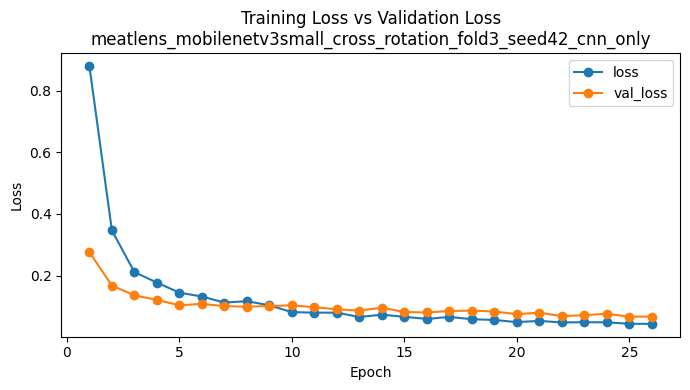

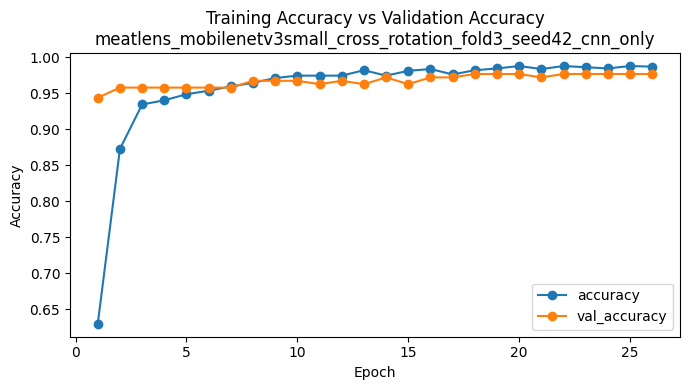

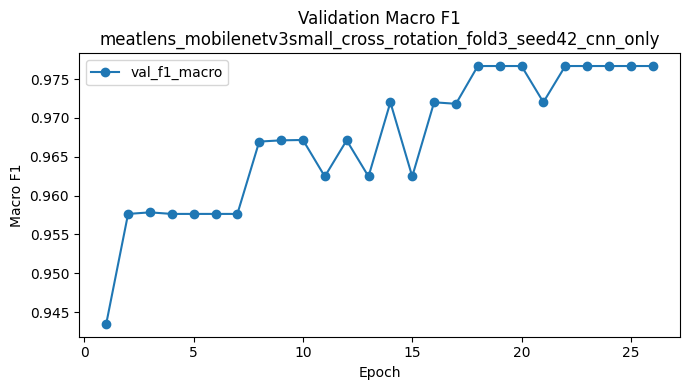

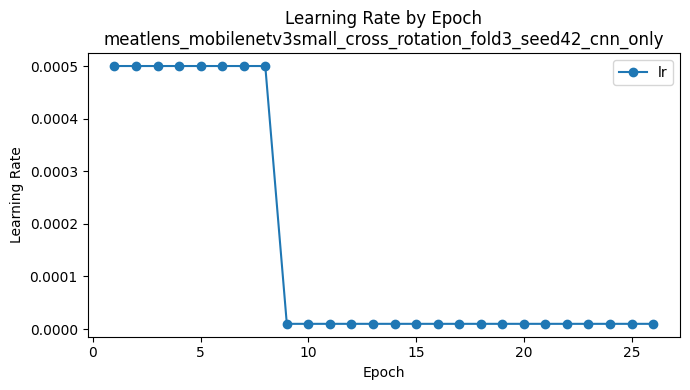

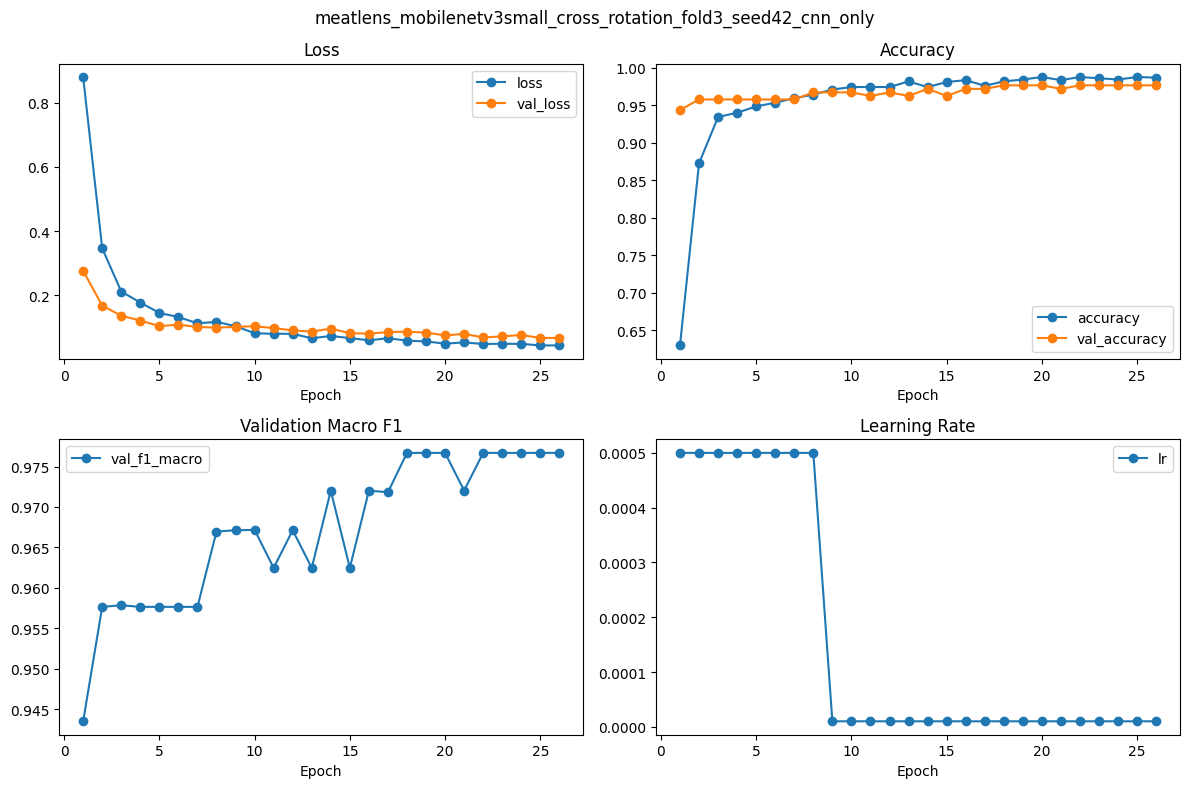

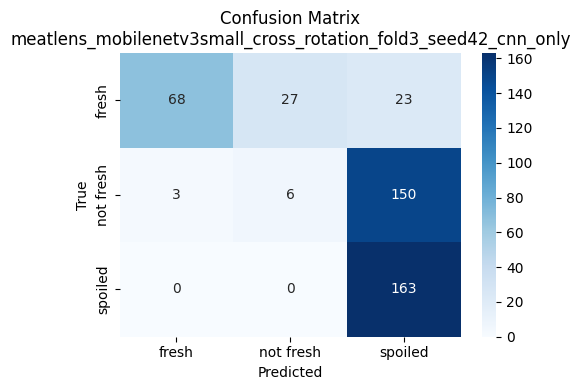

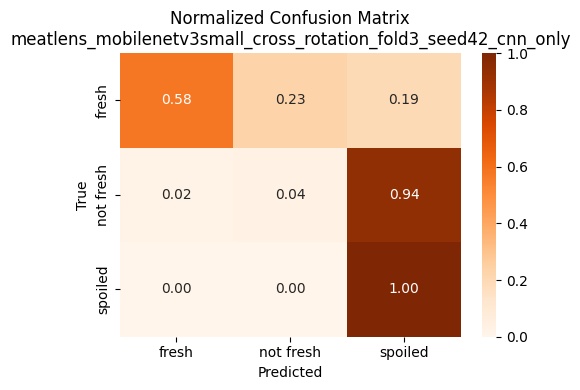

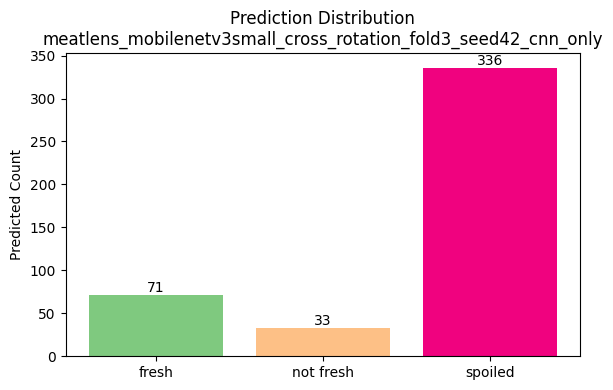

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp4fixfjzz\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp4fixfjzz\assets



################################################################
RUN -> split_mode=cross_rotation | split_name=fold3 | backbone=MobileNetV3Small | seed=123
################################################################

Training run started
split mode      : cross_rotation
split name      : fold3
held-out sample : pork_belly_sample_3
held-out cut    : belly
backbone        : MobileNetV3Small
seed            : 123
train count     : 1199
validation count: 212
test count      : 440
class weights   : {0: 1.0195578231292517, 1: 1.0380952380952382, 2: 0.9470774091627172}
current phase   : head training
Epoch 1/8
38/38 [==============================] - ETA: 0s - loss: 0.7808 - accuracy: 0.6547[head training] epoch=01 loss=0.7808 acc=0.6547 val_loss=0.2538 val_acc=0.9387 val_f1_macro=0.9394 lr=0.00050000

Epoch 1: val_f1_macro improved from -inf to 0.93940, saving model to e:\Thesis Code\training_outputs\models\checkpoints\meatlens_mobilenetv3small_cross_rotation_fold3_seed123_cnn_only_bes

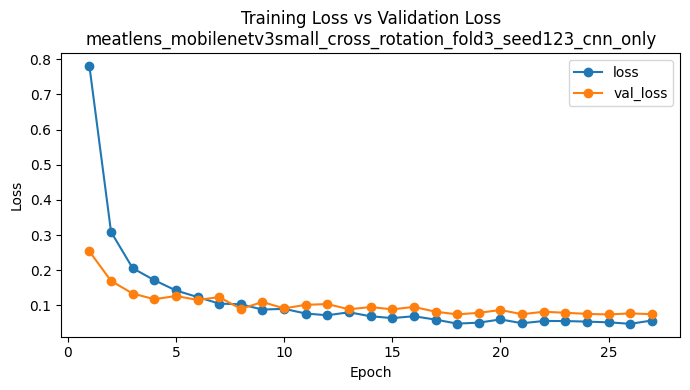

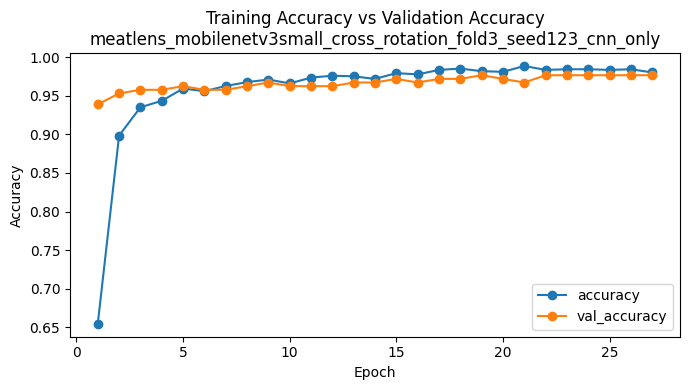

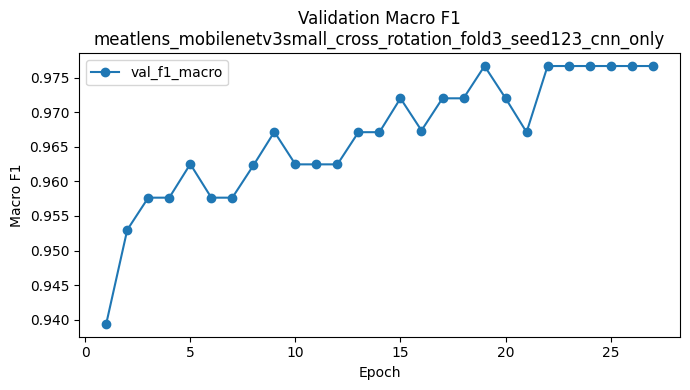

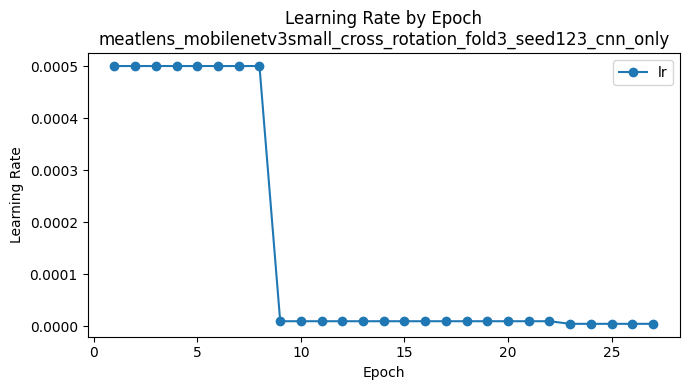

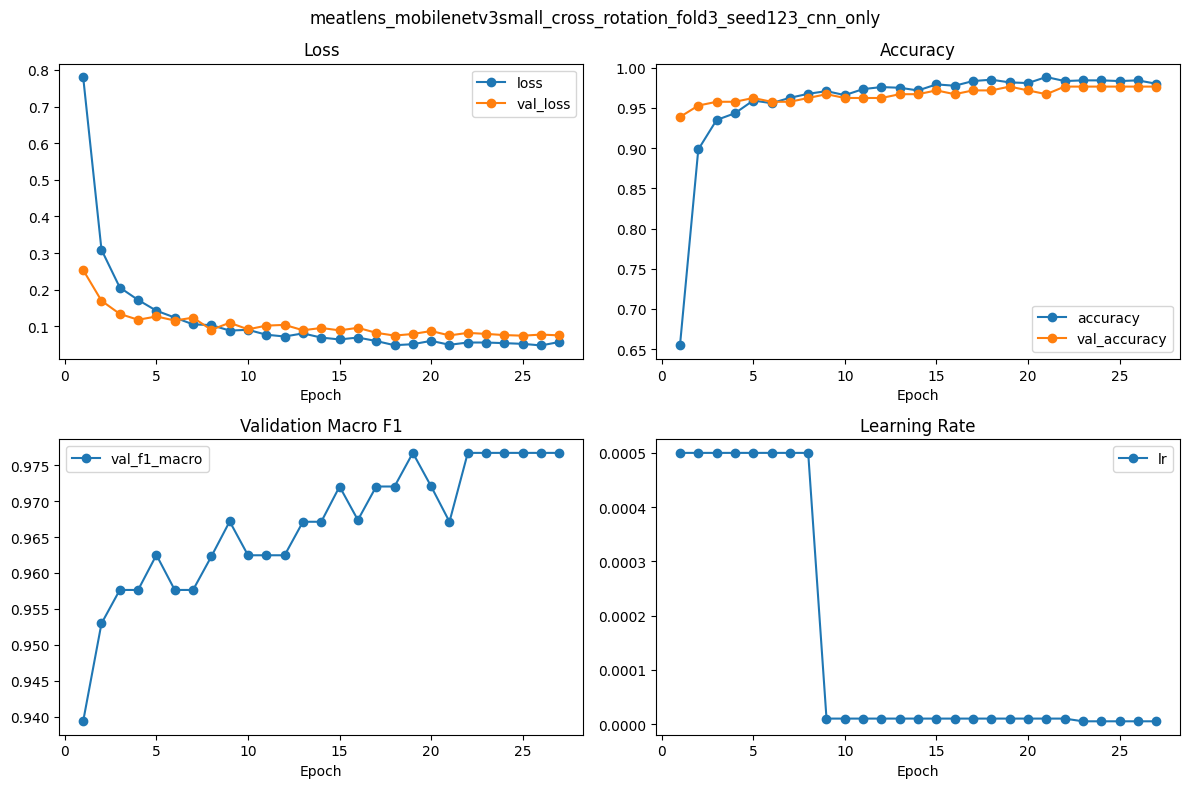

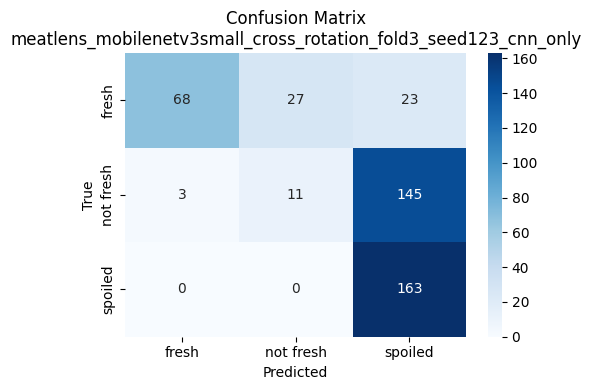

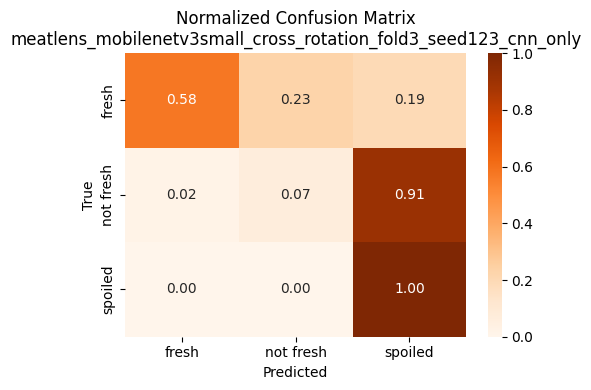

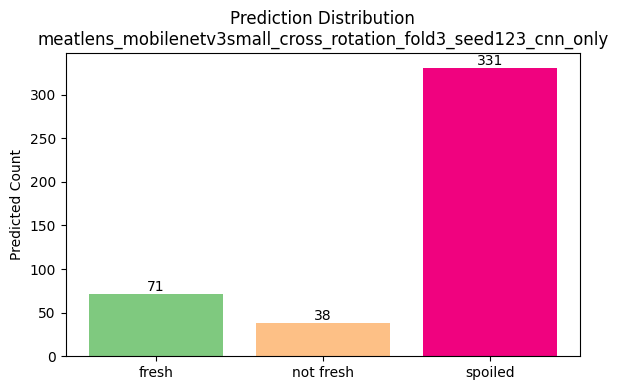

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpkuco2uky\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpkuco2uky\assets



################################################################
RUN -> split_mode=cross_rotation | split_name=fold3 | backbone=MobileNetV3Small | seed=2026
################################################################

Training run started
split mode      : cross_rotation
split name      : fold3
held-out sample : pork_belly_sample_3
held-out cut    : belly
backbone        : MobileNetV3Small
seed            : 2026
train count     : 1199
validation count: 212
test count      : 440
class weights   : {0: 1.0195578231292517, 1: 1.0380952380952382, 2: 0.9470774091627172}
current phase   : head training
Epoch 1/8
38/38 [==============================] - ETA: 0s - loss: 0.9568 - accuracy: 0.5738[head training] epoch=01 loss=0.9568 acc=0.5738 val_loss=0.3379 val_acc=0.9387 val_f1_macro=0.9394 lr=0.00050000

Epoch 1: val_f1_macro improved from -inf to 0.93941, saving model to e:\Thesis Code\training_outputs\models\checkpoints\meatlens_mobilenetv3small_cross_rotation_fold3_seed2026_cnn_only_

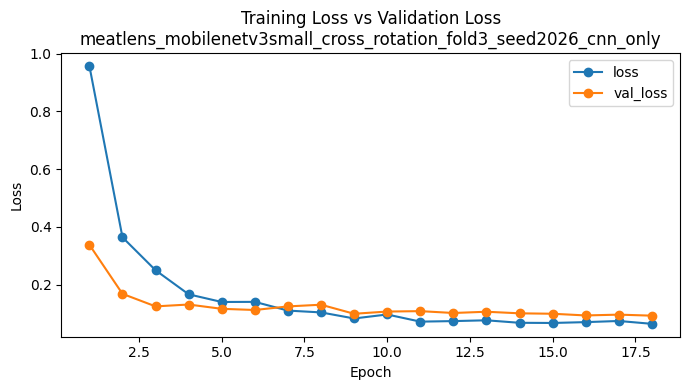

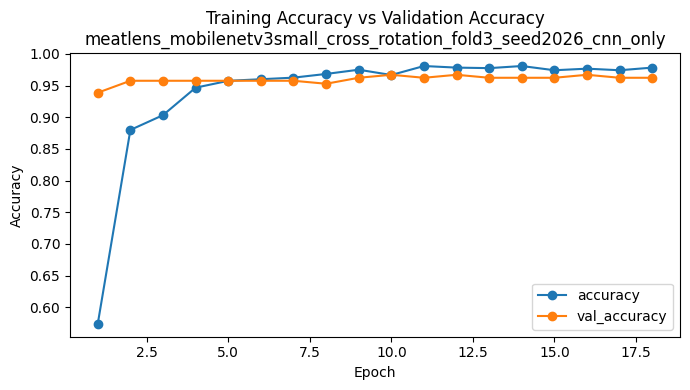

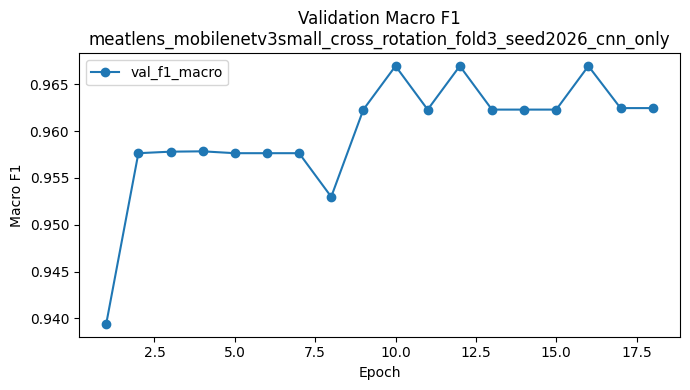

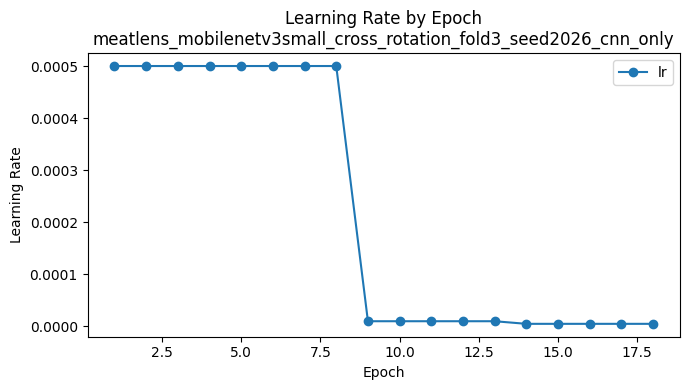

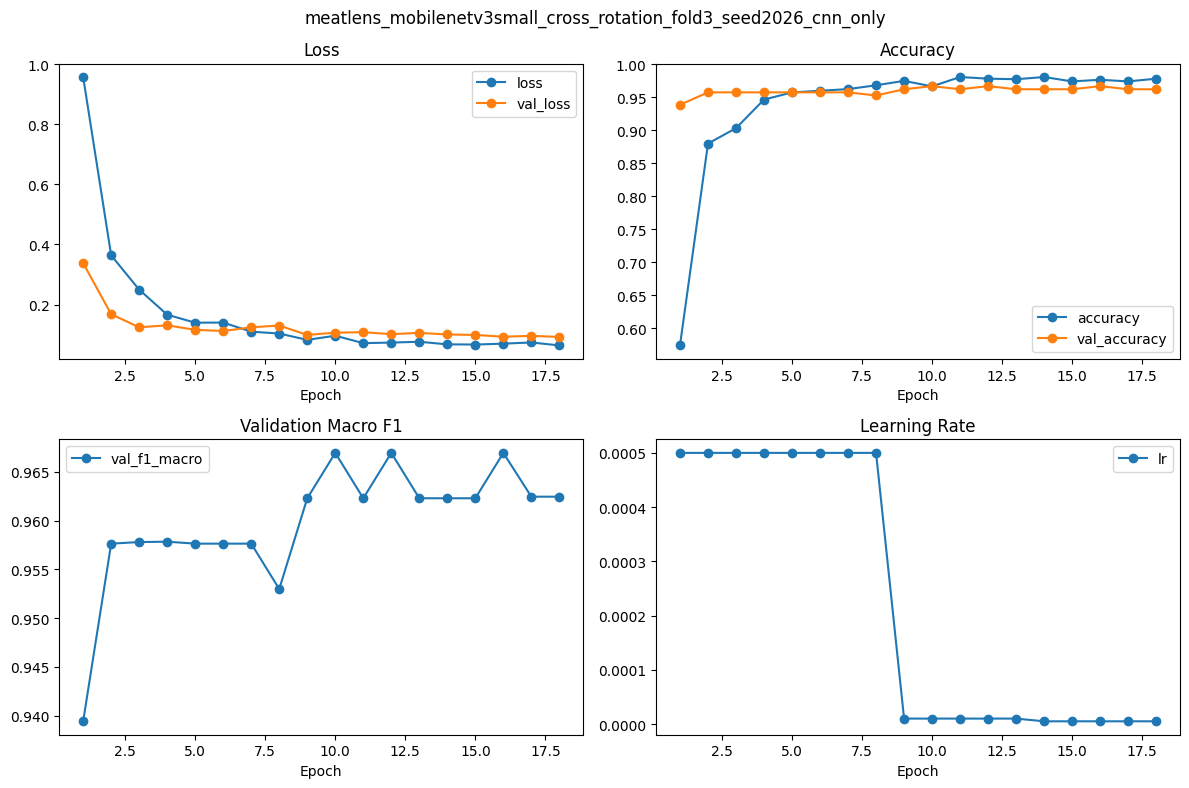

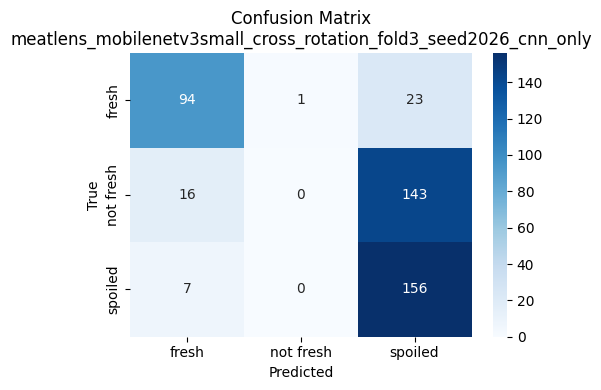

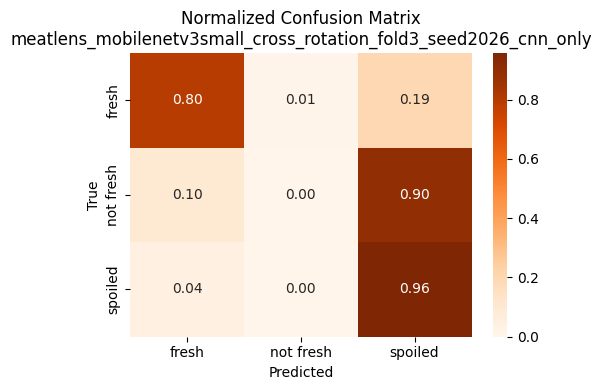

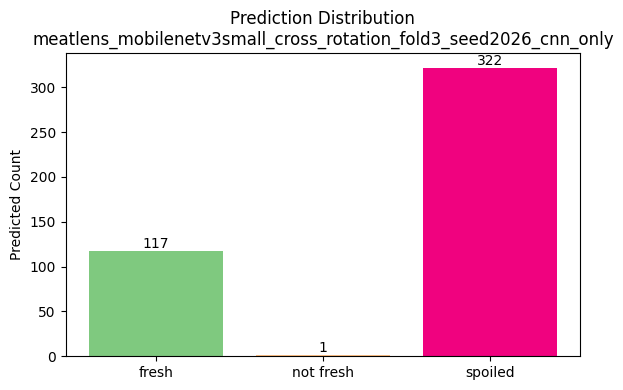

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp11ntn8mb\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp11ntn8mb\assets



################################################################
RUN -> split_mode=cross_rotation | split_name=fold3 | backbone=EfficientNetB0 | seed=42
################################################################

Training run started
split mode      : cross_rotation
split name      : fold3
held-out sample : pork_belly_sample_3
held-out cut    : belly
backbone        : EfficientNetB0
seed            : 42
train count     : 1199
validation count: 212
test count      : 440
class weights   : {0: 1.0195578231292517, 1: 1.0380952380952382, 2: 0.9470774091627172}
current phase   : head training
Epoch 1/8
38/38 [==============================] - ETA: 0s - loss: 0.5435 - accuracy: 0.7990[head training] epoch=01 loss=0.5435 acc=0.7990 val_loss=0.1772 val_acc=0.9575 val_f1_macro=0.9579 lr=0.00050000

Epoch 1: val_f1_macro improved from -inf to 0.95794, saving model to e:\Thesis Code\training_outputs\models\checkpoints\meatlens_efficientnetb0_cross_rotation_fold3_seed42_cnn_only_best.keras
[

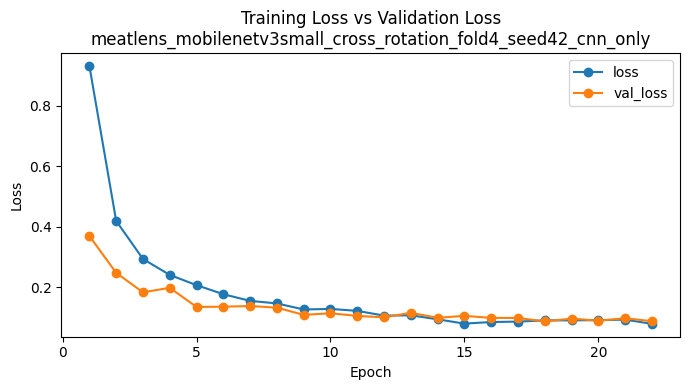

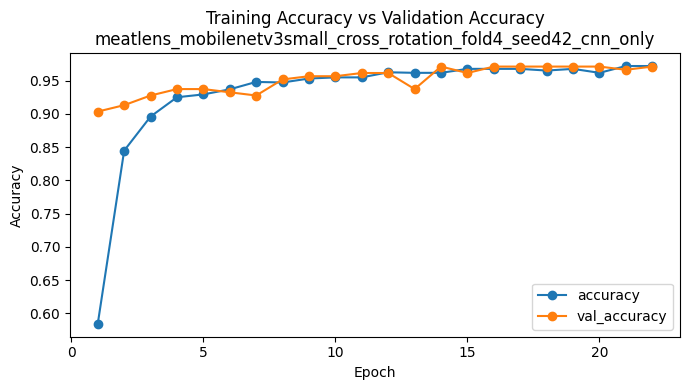

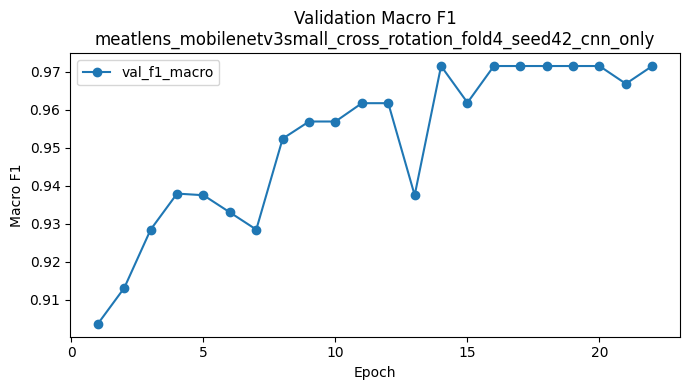

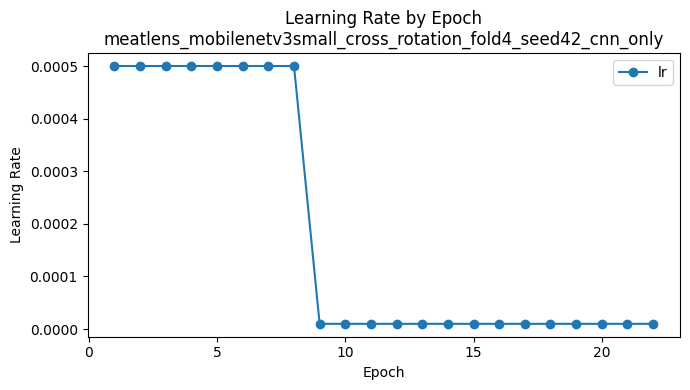

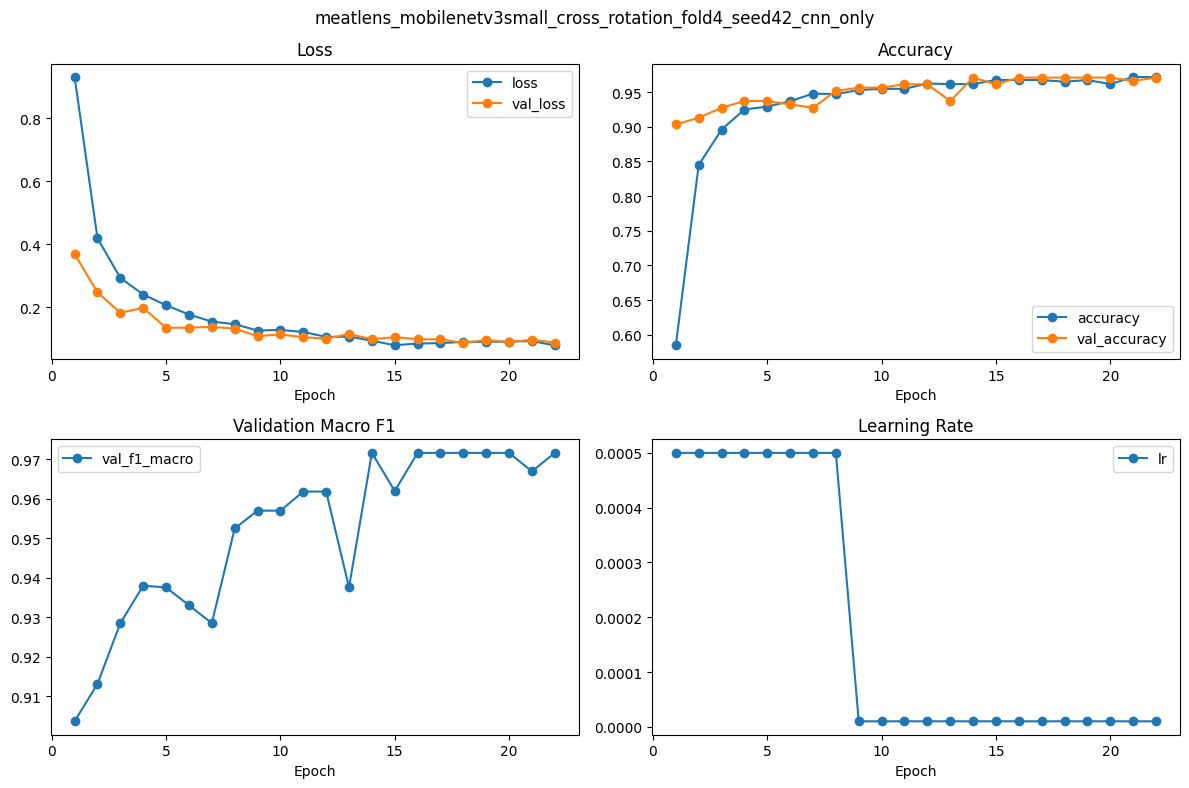

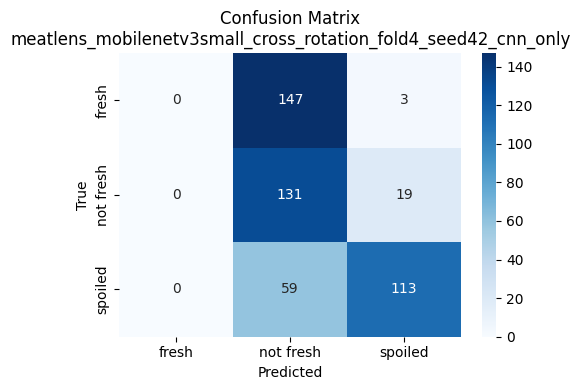

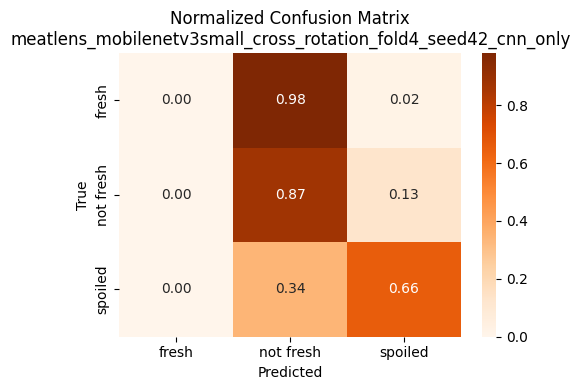

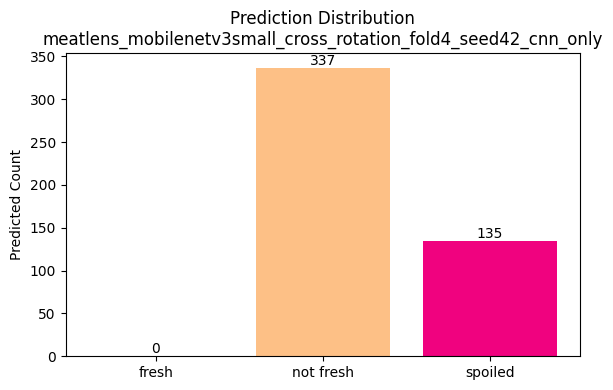

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpagr4d1pz\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpagr4d1pz\assets



################################################################
RUN -> split_mode=cross_rotation | split_name=fold4 | backbone=MobileNetV3Small | seed=123
################################################################

Training run started
split mode      : cross_rotation
split name      : fold4
held-out sample : pork_belly_sample_4
held-out cut    : belly
backbone        : MobileNetV3Small
seed            : 123
train count     : 1172
validation count: 207
test count      : 472
class weights   : {0: 1.0732600732600732, 1: 0.9940627650551315, 2: 0.9413654618473896}
current phase   : head training
Epoch 1/8
37/37 [==============================] - ETA: 0s - loss: 0.7373 - accuracy: 0.6997[head training] epoch=01 loss=0.7373 acc=0.6997 val_loss=0.3026 val_acc=0.9130 val_f1_macro=0.9131 lr=0.00050000

Epoch 1: val_f1_macro improved from -inf to 0.91311, saving model to e:\Thesis Code\training_outputs\models\checkpoints\meatlens_mobilenetv3small_cross_rotation_fold4_seed123_cnn_only_bes

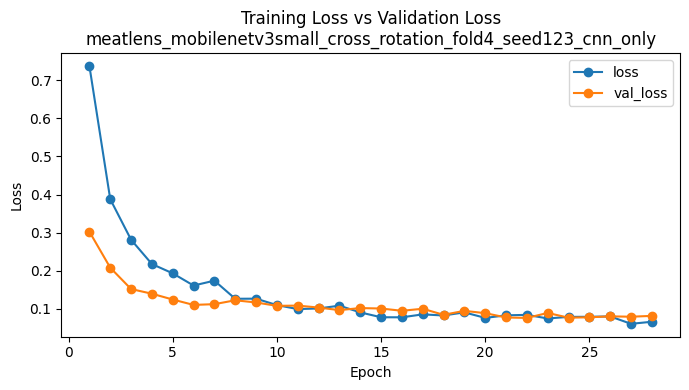

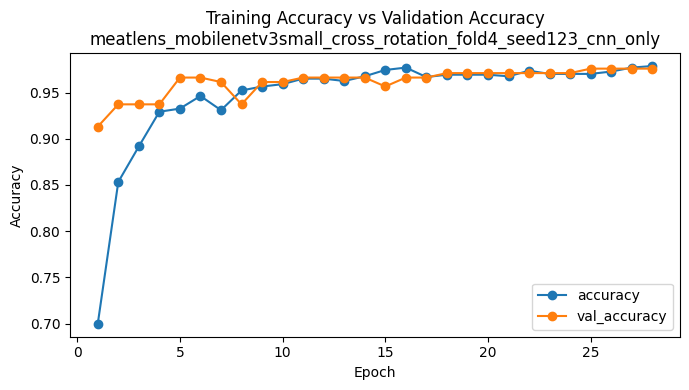

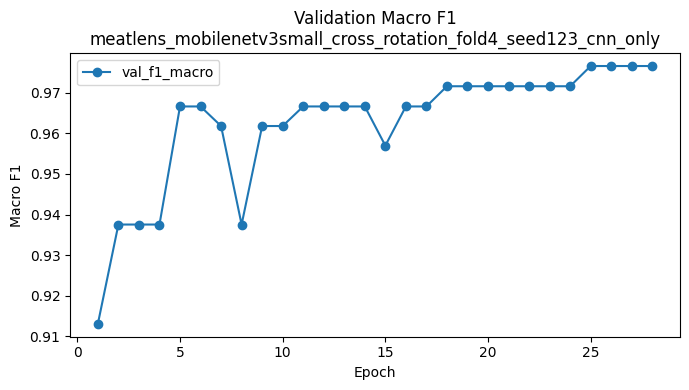

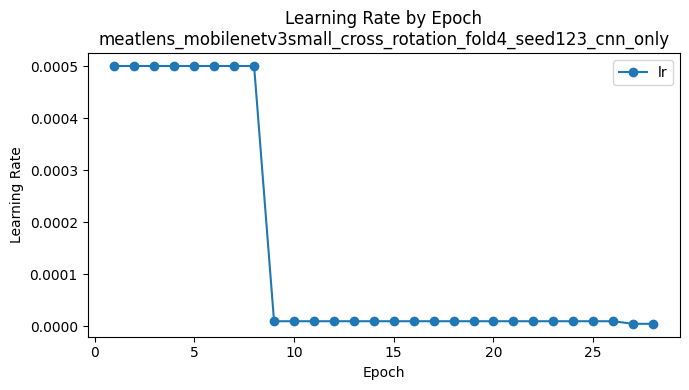

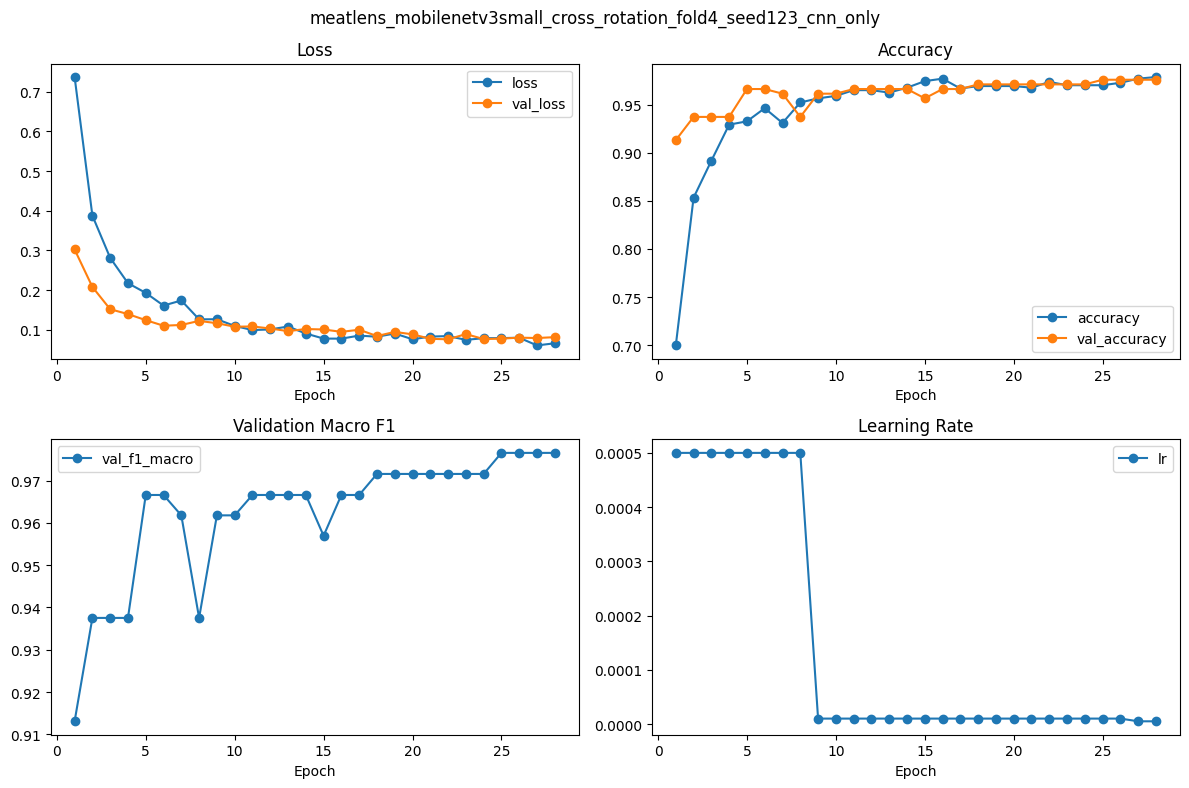

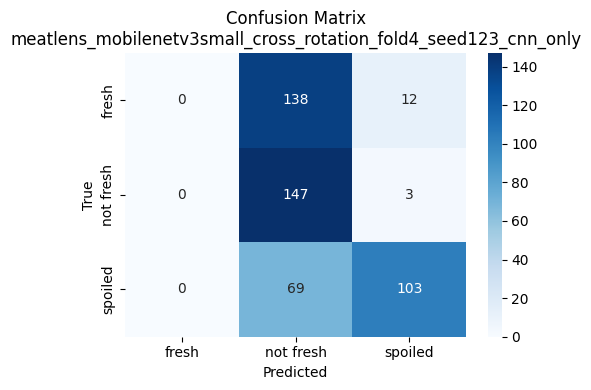

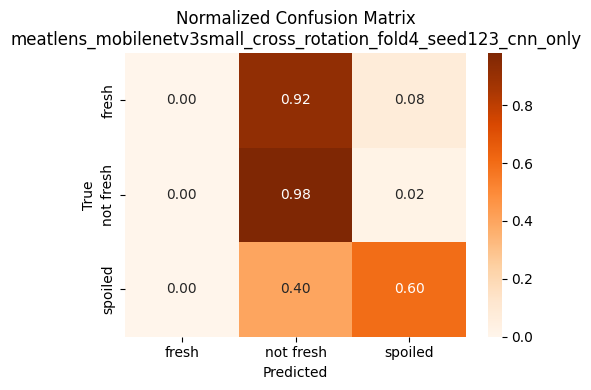

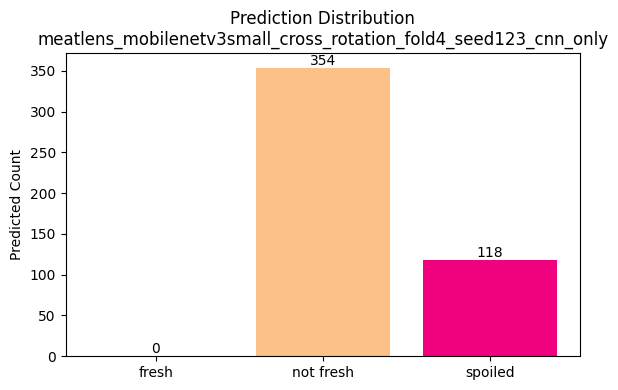

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmptc0qowih\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmptc0qowih\assets



################################################################
RUN -> split_mode=cross_rotation | split_name=fold4 | backbone=MobileNetV3Small | seed=2026
################################################################

Training run started
split mode      : cross_rotation
split name      : fold4
held-out sample : pork_belly_sample_4
held-out cut    : belly
backbone        : MobileNetV3Small
seed            : 2026
train count     : 1172
validation count: 207
test count      : 472
class weights   : {0: 1.0732600732600732, 1: 0.9940627650551315, 2: 0.9413654618473896}
current phase   : head training
Epoch 1/8
37/37 [==============================] - ETA: 0s - loss: 0.9458 - accuracy: 0.5879[head training] epoch=01 loss=0.9458 acc=0.5879 val_loss=0.3951 val_acc=0.8937 val_f1_macro=0.8948 lr=0.00050000

Epoch 1: val_f1_macro improved from -inf to 0.89485, saving model to e:\Thesis Code\training_outputs\models\checkpoints\meatlens_mobilenetv3small_cross_rotation_fold4_seed2026_cnn_only_

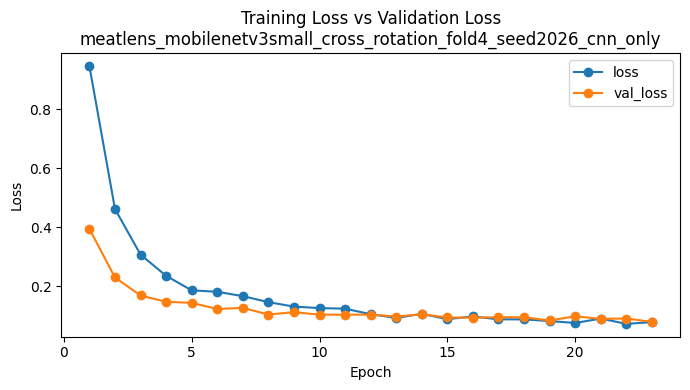

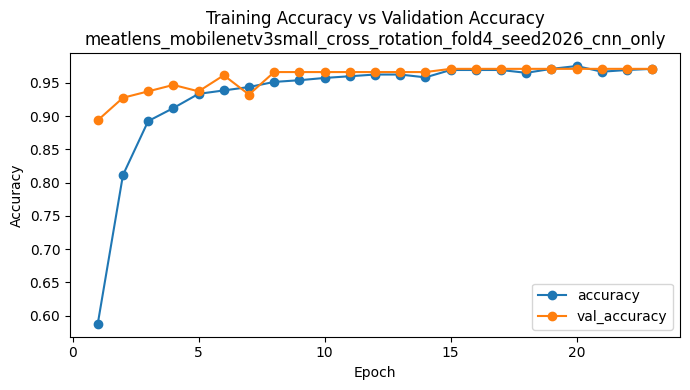

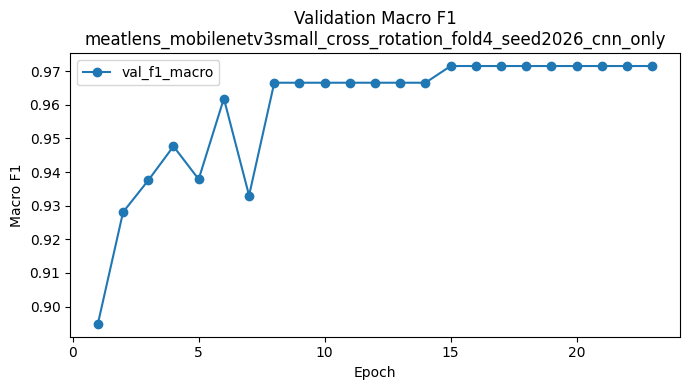

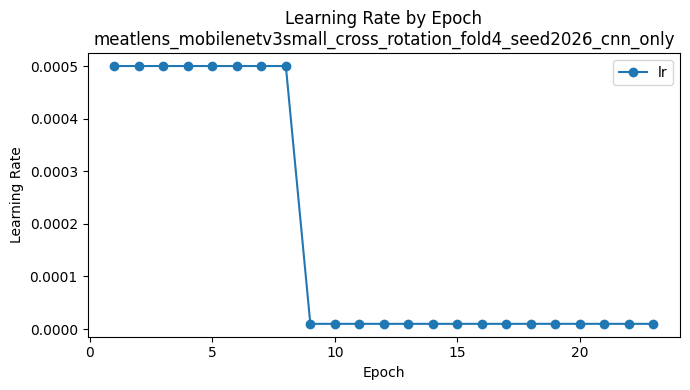

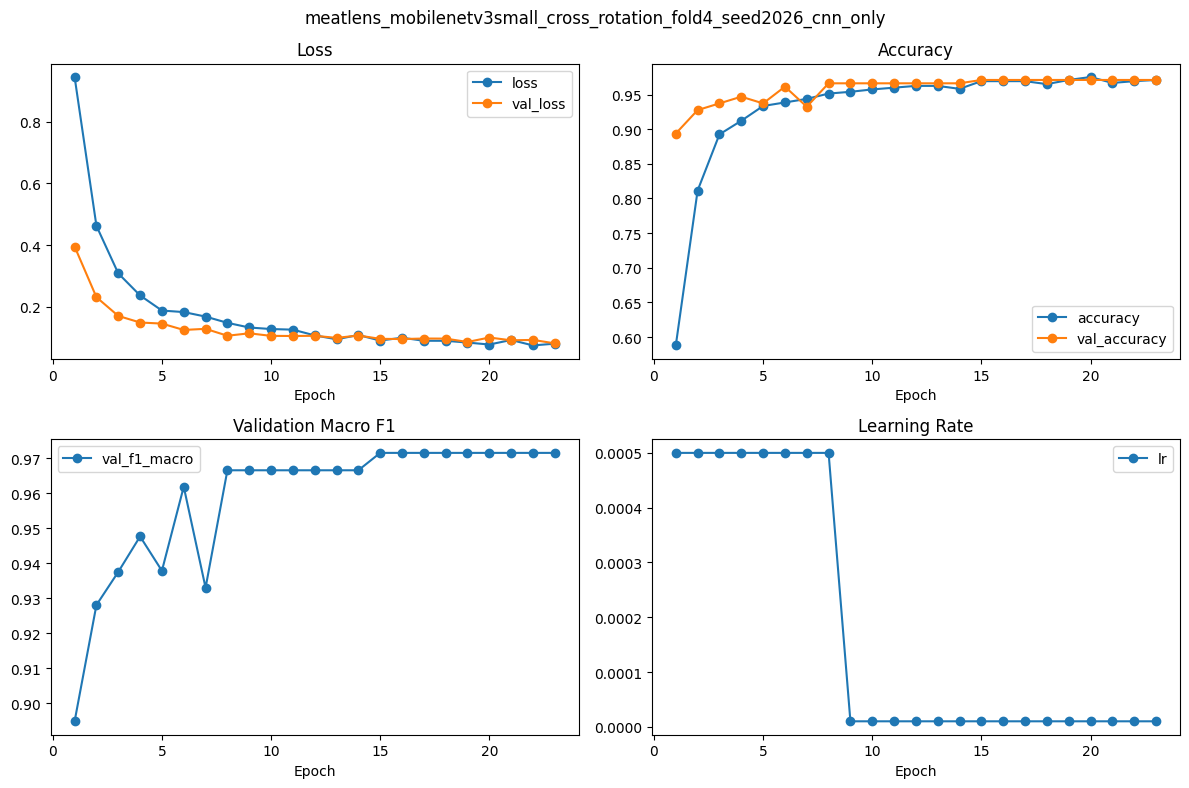

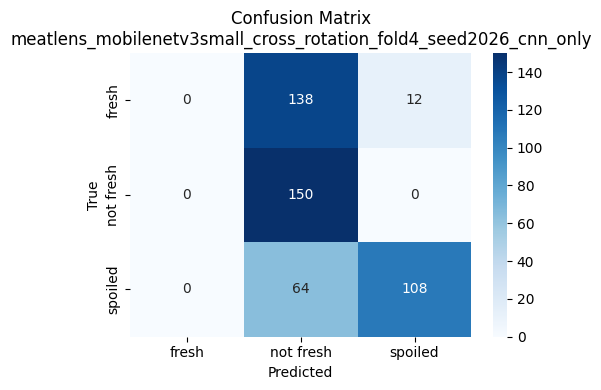

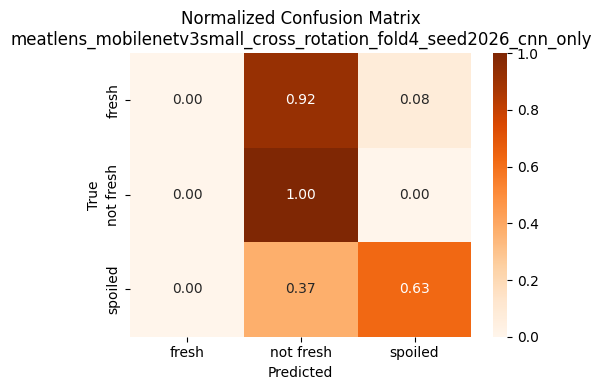

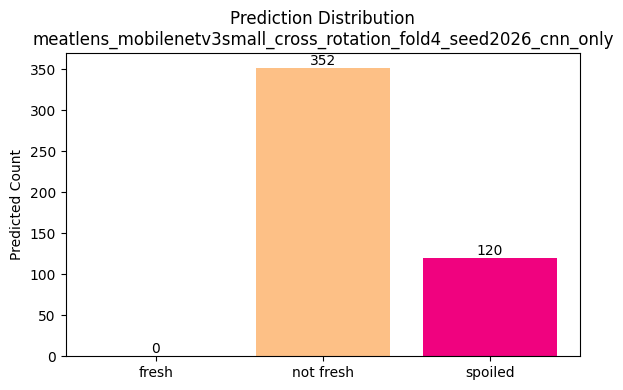

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpz47t6nwu\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpz47t6nwu\assets



################################################################
RUN -> split_mode=cross_rotation | split_name=fold4 | backbone=EfficientNetB0 | seed=42
################################################################

Training run started
split mode      : cross_rotation
split name      : fold4
held-out sample : pork_belly_sample_4
held-out cut    : belly
backbone        : EfficientNetB0
seed            : 42
train count     : 1172
validation count: 207
test count      : 472
class weights   : {0: 1.0732600732600732, 1: 0.9940627650551315, 2: 0.9413654618473896}
current phase   : head training
Epoch 1/8
37/37 [==============================] - ETA: 0s - loss: 0.5429 - accuracy: 0.7833[head training] epoch=01 loss=0.5429 acc=0.7833 val_loss=0.2353 val_acc=0.9227 val_f1_macro=0.9226 lr=0.00050000

Epoch 1: val_f1_macro improved from -inf to 0.92257, saving model to e:\Thesis Code\training_outputs\models\checkpoints\meatlens_efficientnetb0_cross_rotation_fold4_seed42_cnn_only_best.keras
[

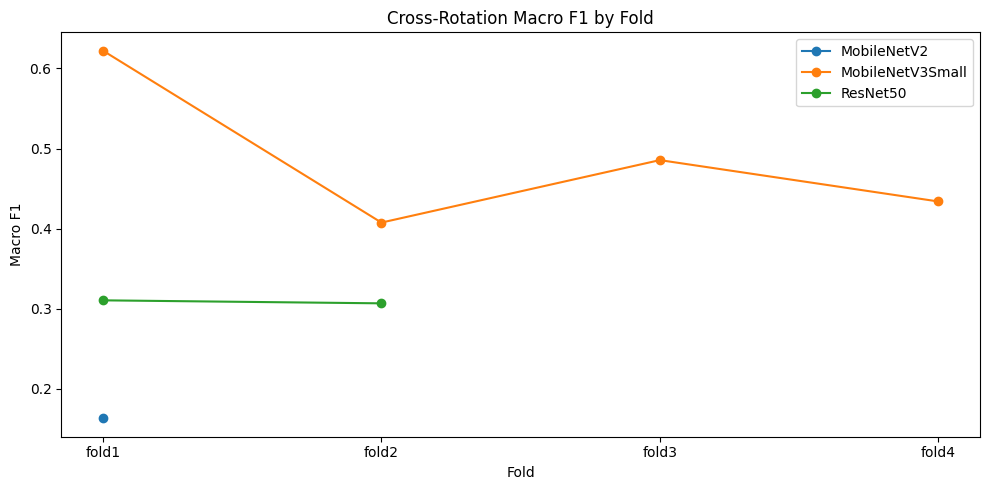

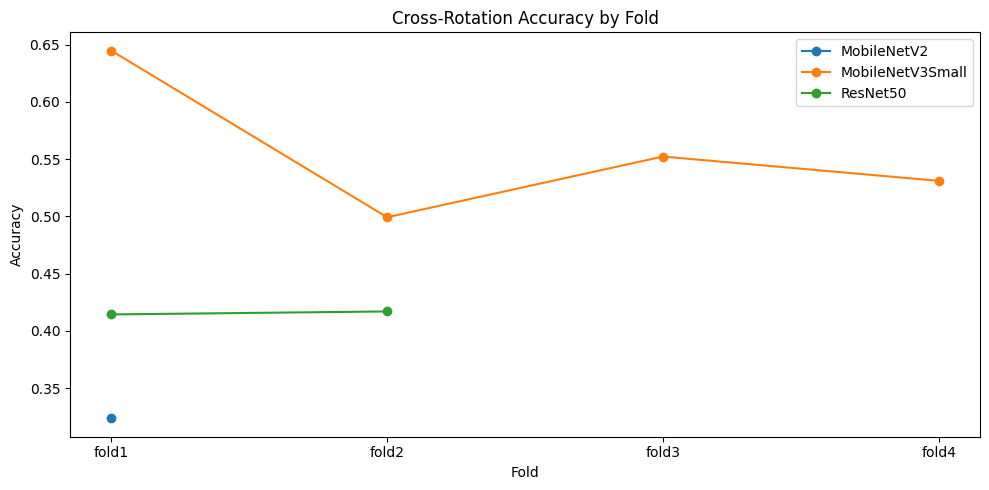

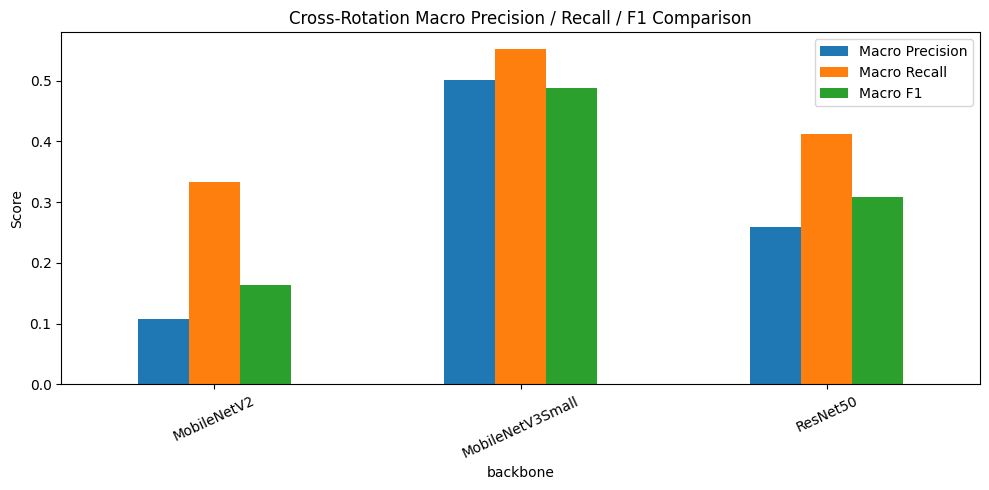

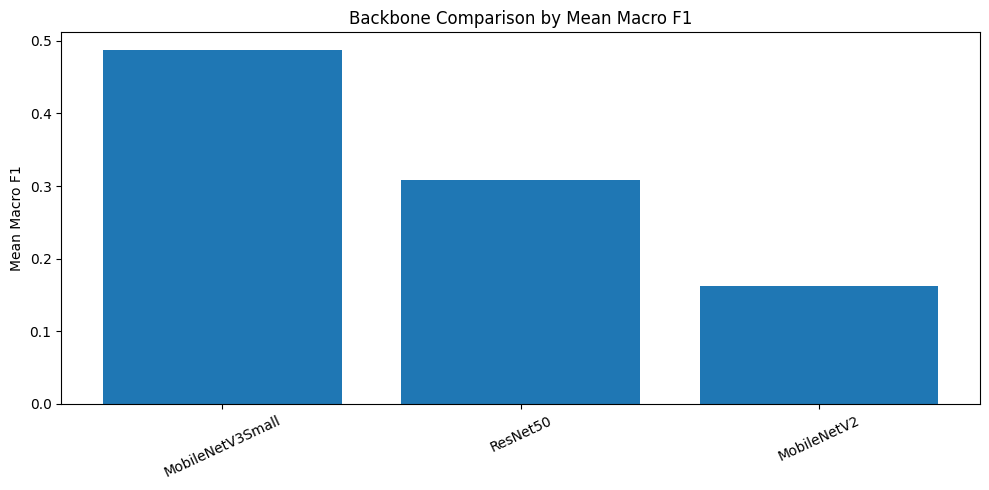

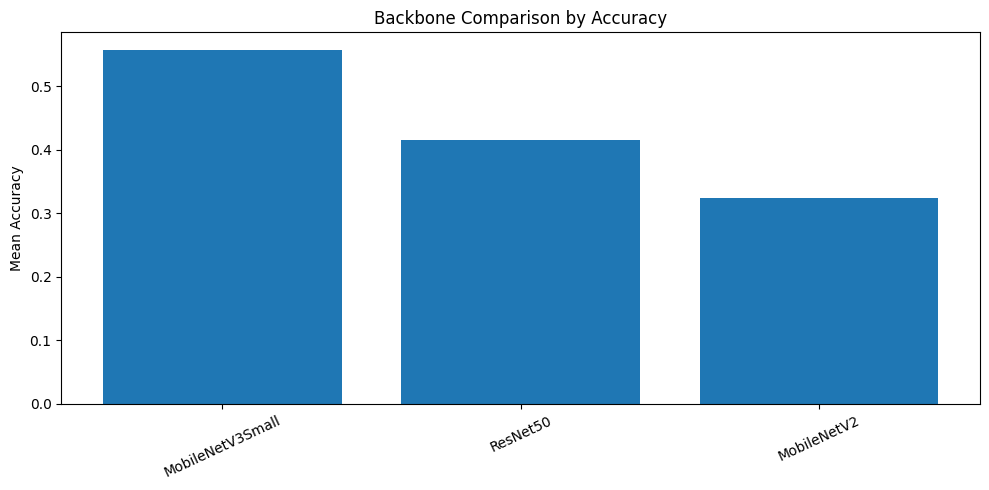

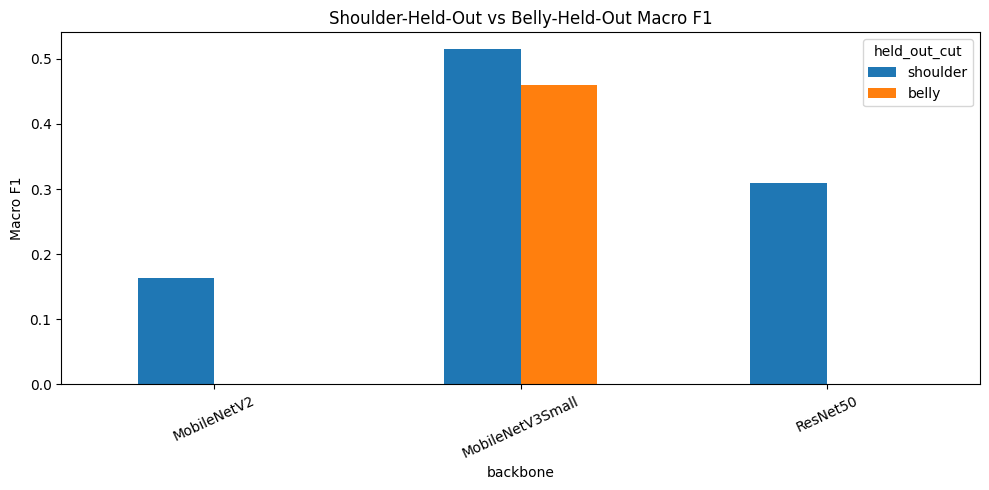

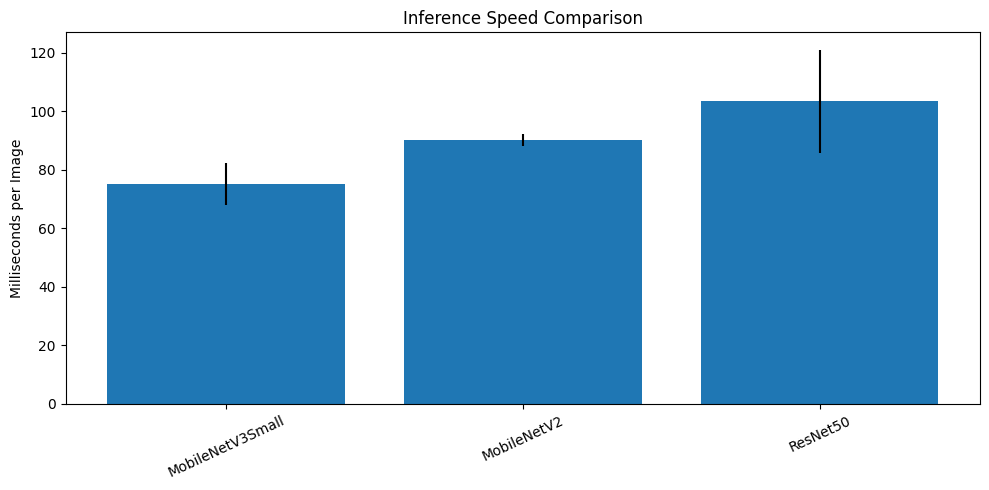

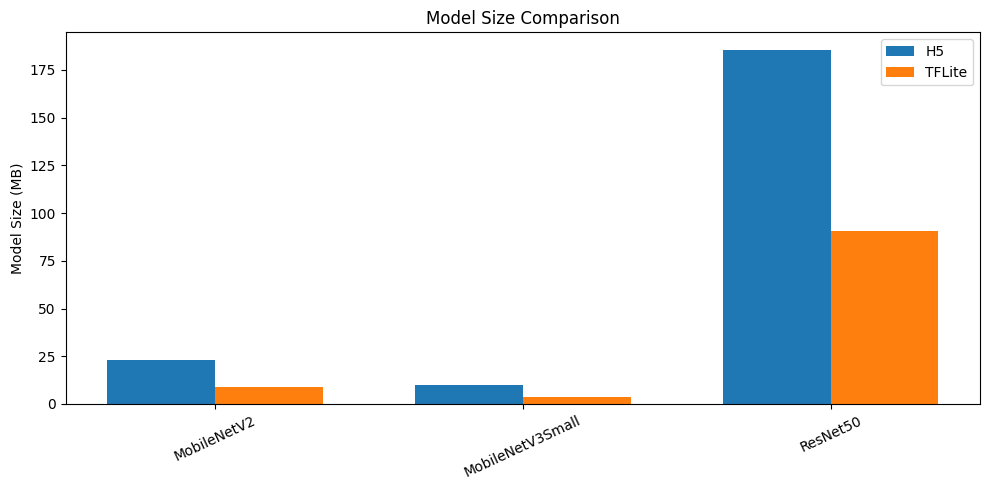

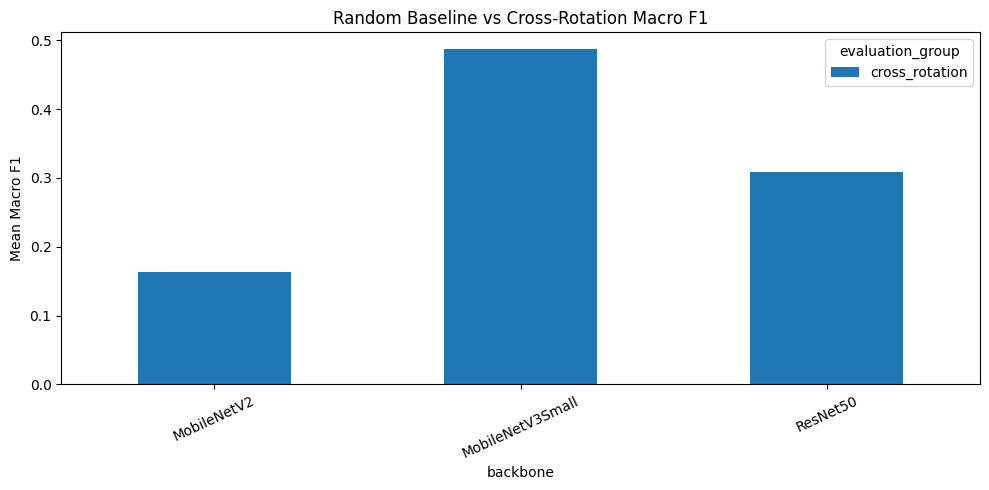

ValueError: Index contains duplicate entries, cannot reshape

In [17]:
# ============================================================
# Main execution cell
# ============================================================
if RUN_FULL_TRAINING:
    all_results = run_cnn_training(backbones=["EfficientNetB0"])
else:
    print("Training functions are ready. Set RUN_FULL_TRAINING=True to run full training.")


In [19]:
# ============================================================
# Final prediction / upload cell
# ============================================================
USER_IMAGE_PATH = "path/to/image.jpg"

def predict_with_best_model(user_image_path=USER_IMAGE_PATH, uploaded_bytes=None, uploaded_name="uploaded_image.jpg"):
    best_model_path = MODELS_DIR / "meatlens_best_model.h5"
    best_metadata_path = MODELS_DIR / "meatlens_best_model_metadata.json"

    if not best_model_path.exists() or not best_metadata_path.exists():
        print("Best model artifacts are not available yet. Run training first.")
        return None

    metadata = json.loads(best_metadata_path.read_text(encoding="utf-8"))
    backbone_name = metadata["backbone"]
    preprocess_fn = BACKBONE_REGISTRY[backbone_name]["preprocess_fn"]
    crop_mode = metadata.get("image_crop_mode", "center_crop")

    if uploaded_bytes is not None:
        temp_path = TRAINING_OUTPUTS / uploaded_name
        temp_path.write_bytes(uploaded_bytes)
        image_path = str(temp_path)
    else:
        image_path = user_image_path

    if not Path(image_path).exists():
        print(f"Image not found: {image_path}")
        return None

    proc, orig = load_image_for_model(
        path=image_path,
        image_crop_mode=crop_mode,
        target_size=tuple(metadata.get("input_size", [224, 224])),
        row=None,
    )
    x = preprocess_fn(proc * 255.0)
    x = np.expand_dims(x.astype(np.float32), axis=0)

    model = tf.keras.models.load_model(best_model_path, compile=False)
    probs = model.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_class = metadata["label_order"][pred_idx]
    confidence = float(probs[pred_idx])
    score = freshness_score(pred_class, confidence)
    recommendation = recommendation_from_score(score)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(orig)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(proc)
    axes[1].set_title(f"Processed 224x224 | {crop_mode}")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    prob_dict = {metadata["label_order"][i]: float(probs[i]) for i in range(len(probs))}
    print("predicted_class:", pred_class)
    print("confidence:", round(confidence, 4))
    print("freshness_score:", round(score, 2))
    print("recommendation:", recommendation)
    print("class_probabilities:", prob_dict)
    print("The freshness score is a rule-based decision-support score derived from model confidence, not a direct biochemical measurement.")

    return {
        "predicted_class": pred_class,
        "confidence": confidence,
        "freshness_score": score,
        "recommendation": recommendation,
        "class_probabilities": prob_dict,
    }


try:
    import ipywidgets as widgets
    from IPython.display import display
    IPYWIDGETS_AVAILABLE = True
except Exception:
    IPYWIDGETS_AVAILABLE = False

if IPYWIDGETS_AVAILABLE:
    print("ipywidgets upload is available.")
    upload_widget = widgets.FileUpload(accept="image/*", multiple=False)
    display(upload_widget)
    print("After uploading, run:")
    print("if upload_widget.value:")
    print("    uploaded_item = list(upload_widget.value.values())[0]")
    print("    predict_with_best_model(uploaded_bytes=uploaded_item['content'], uploaded_name=uploaded_item['name'])")
else:
    print("ipywidgets is not available. Use USER_IMAGE_PATH instead.")

# Example manual usage after training:
# prediction_result = predict_with_best_model(USER_IMAGE_PATH)


ipywidgets upload is available.


FileUpload(value=(), accept='image/*', description='Upload')

After uploading, run:
if upload_widget.value:
    uploaded_item = list(upload_widget.value.values())[0]
    predict_with_best_model(uploaded_bytes=uploaded_item['content'], uploaded_name=uploaded_item['name'])


In [20]:
if upload_widget.value:
    uploaded_item = list(upload_widget.value.values())[0]
    predict_with_best_model(uploaded_bytes=uploaded_item['content'], uploaded_name=uploaded_item['name'])

AttributeError: 'tuple' object has no attribute 'values'

In [ ]:
# ============================================================
# Final notebook summary
# ============================================================
print("Notebook ready for the final MeatLens CNN-only thesis run.")
print("Primary evaluation: cross_rotation")
print("Secondary baseline: random_70_15_15")
print("Primary comparison metric: macro F1")
